# LeafletFA Splicing Analysis - Mouse Foundation Model
 
### This notebook analyzes the relationship between splicing factors (LeafletFA) and gene expression factors (scVI, NMF, PCA) for age prediction across different cell types.


## 1. Setup and Imports

In [1]:
# %%
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
from pathlib import Path
import os
import sys
from collections import defaultdict

# Statistical libraries
from scipy.stats import spearmanr, pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy import stats
import scipy.sparse as sp
from statsmodels.stats.multitest import multipletests

# Machine learning
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Specialized libraries
import scanpy as sc
from adjustText import adjust_text
from tqdm import tqdm

## 2. Configuration and Path Setup

In [2]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

class Config:
    # Base directories
    BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
    RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results"
    
    # Data paths
    GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_both_scvi_models_latent_20_2025-08-04.h5ad"
    GE_ANNDATA_NMF_PATH = f"{BASE_DIR}/NMF/ge_adata_with_NMF_standard_20_1024_2025-08-03.h5ad"
    
    # GSEA paths
    GSEA_BASE_PATH = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250804"
    
    # Reference files
    AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
    RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"
    ATSE_FILE_PATH = f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
    
    # Main parameters to change
    MODEL_TRAIN_DATE = "2025-07-30"
    MODEL_ANALYSIS_DATE = "2025-07-31"
    PARAM_ID = 0
    
    # Genome database
    MOUSE_DB_FILE = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"

# Generate auto paths
def setup_paths(config):
    """Generate all necessary paths from configuration."""
    param_results_dir = f"{config.RESULTS_BASE_DIR}/{config.MODEL_TRAIN_DATE}/{config.MODEL_ANALYSIS_DATE}/param_id_{config.PARAM_ID}"
    data_dir = f"{param_results_dir}/data"
    model_outputs_dir = f"{config.BASE_DIR}/Leaflet/leafletFAmodel/{config.MODEL_TRAIN_DATE}"
    output_dir = f"{param_results_dir}/analysis_outputs"
    
    paths = {
        'data_dir': data_dir,
        'output_dir': output_dir,
        'splice_adata_path': f"{data_dir}/splice_adata_PHI_psi_var_obs.h5ad",
        'pi_values_path': f"{data_dir}/PI_values.npy",
        'perplexity_path': f"{data_dir}/cell_metadata_with_perplexity_param_id_{config.PARAM_ID}.csv.gz",
        'diff_spl_path': f"{data_dir}/differential_splicing_results.csv",
        'model_path': f"{model_outputs_dir}/run_{config.PARAM_ID}/leafletfa_model.pkl.xz"
    }
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    return paths

config = Config()
paths = setup_paths(config)

print(f"Configuration set for param_id {config.PARAM_ID}")
print(f"Output directory: {paths['output_dir']}")

Configuration set for param_id 0
Output directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs


## 3. Custom Module Imports

In [3]:
# Import LeafletFA differential splicing code
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"
utils_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/"

if src_path not in sys.path:
    sys.path.append(src_path)
if utils_path not in sys.path:
    sys.path.append(utils_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds
from utils import *
from figure_plotting import *
from atse_viz import *
import gffutils

# Load genome database
db_mouse = gffutils.FeatureDB(config.MOUSE_DB_FILE, keep_order=True)

# Import LeafletFA differential splicing code
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"
utils_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/"

if src_path not in sys.path:
    sys.path.append(src_path)
if utils_path not in sys.path:
    sys.path.append(utils_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds
from utils import *
from figure_plotting import *
from atse_viz import *
import gffutils

# Load genome database
db_mouse = gffutils.FeatureDB(config.MOUSE_DB_FILE, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


## 4. Data Loading Functions

In [4]:
def load_gsea_data(base_path):
    """Load all GSEA data files."""
    gsea_data = {}
    
    methods = ['scvi'] #, 'nmf', 'pca']
    for method in methods:
        gsea_data[method] = {
            'full': pd.read_csv(f"{base_path}/gsea_results_comprehensive_{method}.tsv.gz", sep="\t")
        }
    
    return gsea_data

def load_reference_genes(aging_genes_path, rbp_file_path):
    """Load aging genes and RBP genes."""
    aging_genes_mouse, aging_genes_human = load_aging_genes(aging_genes_path)
    rbps = load_rbp_genes(rbp_file_path)
    
    # Process gene names
    rbps["mouse_gene_name"] = rbps["mouse_gene_name"].str.upper()
    aging_genes_mouse = [g.upper() for g in aging_genes_mouse]
    
    return aging_genes_mouse, rbps

def load_main_datasets(config, paths):
    """Load main AnnData objects and associated data."""
    print("Loading main datasets...")
    
    # Load gene expression data
    # ge_adata_nmf = ad.read_h5ad(config.GE_ANNDATA_NMF_PATH)
    ge_adata = ad.read_h5ad(config.GE_ANNDATA_scVI_PATH)
    
    # Combine data
    # assert np.all(ge_adata.obs_names == ge_adata_nmf.obs_names), "Cell ID mismatch"
    # assert np.all(ge_adata.var_names == ge_adata_nmf.var_names), "Gene name mismatch"
    
    # ge_adata.obsm["X_nmf_standard_mb"] = ge_adata_nmf.obsm["X_nmf_standard_mb"]
    # ge_adata.varm["nmf_standard_mb_components"] = ge_adata_nmf.varm["nmf_standard_mb_components"]
    # ge_adata.obsm["X_pca"] = ge_adata_nmf.obsm["X_pca"]
    # ge_adata.varm["pca_loadings"] = ge_adata_nmf.varm["pca_loadings"]
    
    # Add gene names if missing
    if "gene_name" not in ge_adata.var.columns:
        ge_adata.var["gene_name"] = ge_adata.var_names
    if "cell_id" not in ge_adata.obs.columns:
        ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]
    
    # Load splicing data
    splice_adata = ad.read_h5ad(paths['splice_adata_path'])
    pi = np.load(paths['pi_values_path'])
    diff_spl = pd.read_csv(paths['diff_spl_path'])
    perplexity_df = pd.read_csv(paths['perplexity_path']).set_index("cell_id")
    
    print(f"Loaded splice_adata: {splice_adata.shape}")
    print(f"Loaded ge_adata: {ge_adata.shape}")
    
    return ge_adata, splice_adata, pi, diff_spl, perplexity_df

## 5. Data Processing Functions

In [5]:
def process_splice_data(splice_adata, pi, diff_spl, perplexity_df):
    """Process and reorder splicing data based on PI values."""
    print("Processing splicing data...")
    
    # Fix sex column
    sex_str = splice_adata.obs["sex"].astype(str)
    sex_fixed = sex_str.replace({"M": "male", "F": "female"})
    splice_adata.obs["sex"] = pd.Categorical(sex_fixed)
    
    # Rename mouse.id to donor_id if exists
    if "mouse.id" in splice_adata.obs.columns:
        splice_adata.obs.rename(columns={"mouse.id": "donor_id"}, inplace=True)
    
    # Add perplexity
    splice_adata.obs_names = splice_adata.obs["cell_id"]
    assert all(splice_adata.obs_names == perplexity_df.index), "Cell ID mismatch with perplexity"
    splice_adata.obs["perplexity"] = perplexity_df["perplexity"]
    
    # Reorder factors by PI values
    K = splice_adata.obsm["X_PHI"].shape[1]
    new_order = np.argsort(-pi)  # Descending order
    
    print("Factor reordering based on PI values:")
    for rank, idx in enumerate(new_order[:5]):  # Show top 5
        print(f"Rank {rank + 1}: Factor {idx} → PI = {pi[idx]:.4f}")
    
    # Create mapping
    old_to_new_factor_idx = {old: new for new, old in enumerate(new_order)}
    
    # Reorder matrices
    splice_adata.obsm["X_PHI"] = splice_adata.obsm["X_PHI"][:, new_order]
    splice_adata.varm["psi_learned"] = splice_adata.varm["psi_learned"][:, new_order]
    
    # Add factor columns to obs
    phi_colnames = [f"SP_{i+1}" for i in range(K)]
    phi_df = pd.DataFrame(
        splice_adata.obsm["X_PHI"], 
        index=splice_adata.obs_names,
        columns=phi_colnames
    )
    splice_adata.obs = pd.concat([splice_adata.obs, phi_df], axis=1)
    
    # Update differential splicing results
    diff_spl = diff_spl.rename(columns={"factor_idx": "old_factor_idx"})
    diff_spl["factor_idx"] = diff_spl["old_factor_idx"].map(old_to_new_factor_idx)
    
    return splice_adata, diff_spl

def annotate_genes(ge_adata, aging_genes_mouse, rbps):
    """Annotate genes with aging and RBP information."""
    ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["mouse_gene_name"])
    ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_mouse)
    return ge_adata

def filter_cell_types(splice_adata, ge_adata, min_cells=50):
    """Filter to cell types with sufficient cells."""
    valid_medium_ct = (
        splice_adata.obs["medium_cell_type"]
        .value_counts()[lambda x: x >= min_cells]
        .index
    )
    
    print(f"Keeping {len(valid_medium_ct)} cell types with >= {min_cells} cells")
    
    splice_adata = splice_adata[splice_adata.obs["medium_cell_type"].isin(valid_medium_ct)].copy()
    ge_adata = ge_adata[ge_adata.obs["medium_cell_type"].isin(valid_medium_ct)].copy()
    
    assert np.all(ge_adata.obs_names == splice_adata.obs_names), "Cell order mismatch after filtering"
    
    return splice_adata, ge_adata

## 6. Main Data Loading and Processing

In [6]:
# Load GSEA data
print("Loading GSEA data...")
gsea_data = load_gsea_data(config.GSEA_BASE_PATH)

# Load reference genes
print("Loading reference genes...")
aging_genes_mouse, rbps = load_reference_genes(config.AGING_GENES_PATH, config.RBP_FILE_PATH)

# Load main datasets
ge_adata, splice_adata, pi, diff_spl, perplexity_df = load_main_datasets(config, paths)

# Process data
splice_adata, diff_spl = process_splice_data(splice_adata, pi, diff_spl, perplexity_df)
ge_adata = annotate_genes(ge_adata, aging_genes_mouse, rbps)

# Sync additional columns
assert all(splice_adata.obs_names == ge_adata.obs_names)
for col in ["AgingScore_unweighted", "total_counts", "nuclear_class_log_norm", "nuclear_score_log_norm"]:
    if col in ge_adata.obs.columns:
        splice_adata.obs[col] = ge_adata.obs[col]

# Filter cell types
splice_adata, ge_adata = filter_cell_types(splice_adata, ge_adata)

# Clean up cell type names
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].str.title()

print(f"Final data shapes - Splice: {splice_adata.shape}, GE: {ge_adata.shape}")

Loading GSEA data...
Loading reference genes...
Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins
Loading main datasets...
Loaded splice_adata: (137936, 35197)
Loaded ge_adata: (137936, 2482)
Processing splicing data...
Factor reordering based on PI values:
Rank 1: Factor 2 → PI = 0.1451
Rank 2: Factor 0 → PI = 0.1417
Rank 3: Factor 1 → PI = 0.1131
Rank 4: Factor 6 → PI = 0.0708
Rank 5: Factor 12 → PI = 0.0475
Keeping 57 cell types with >= 50 cells
Final data shapes - Splice: (137893, 35197), GE: (137893, 2482)


In [7]:
# filter to cells with age > 2
splice_adata = splice_adata[splice_adata.obs["age_numeric"] > 2].copy()
counts = splice_adata.obs.groupby(["medium_cell_type", "age_group"]).size().unstack(fill_value=0)
eligible_ct = counts.index[(counts["young"] >= 100) & (counts["old"] >= 100)]

# Apply filter
splice_adata = splice_adata[splice_adata.obs["medium_cell_type"].isin(eligible_ct)].copy()
print(f"Number of cell types after filtering: {len(splice_adata.obs['medium_cell_type'].unique())}")
print(f"Number of cells after filtering: {splice_adata.n_obs}")

ge_adata_full = ge_adata.copy()
ge_adata = ge_adata[splice_adata.obs_names].copy()
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

Number of cell types after filtering: 35
Number of cells after filtering: 84047


## 7. Exploratory Data Analysis

In [8]:
def create_age_celltype_heatmap(splice_adata, output_dir):
    """Create heatmap of cell counts by age and cell type."""
    print("Creating age vs cell type heatmap...")
    
    heatmap_data = pd.crosstab(
        splice_adata.obs['medium_cell_type'], 
        splice_adata.obs['age_numeric']
    ).fillna(0)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt='g', 
                cmap='Blues',
                cbar_kws={'label': 'Cell Count'})
    plt.title('Cell Counts by Age and Medium Cell Type')
    plt.xlabel('Age (months)')
    plt.ylabel('Medium Cell Type')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.savefig(f"{output_dir}/age_vs_celltype_heatmap.pdf", bbox_inches='tight')
    plt.show()

def create_factor_boxplots(splice_adata, ge_adata, output_dir):
    """Create boxplots for different factor types."""
    features = {
        'Splicing Factors': splice_adata.obsm["X_PHI"],
        'scVI Factors': ge_adata.obsm["X_scVI_linear"],
       # 'NMF Factors': ge_adata.obsm["X_nmf_standard_mb"],
       # 'PCA Factors': ge_adata.obsm["X_pca"]
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, (name, data) in enumerate(features.items()):
        sns.boxplot(data=data, ax=axes[i])
        axes[i].set_title(f'Distribution of {name}')
        axes[i].set_xlabel('Factor')
        axes[i].set_ylabel('Value')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/factor_distributions.pdf", bbox_inches='tight')
    plt.show()

Creating age vs cell type heatmap...


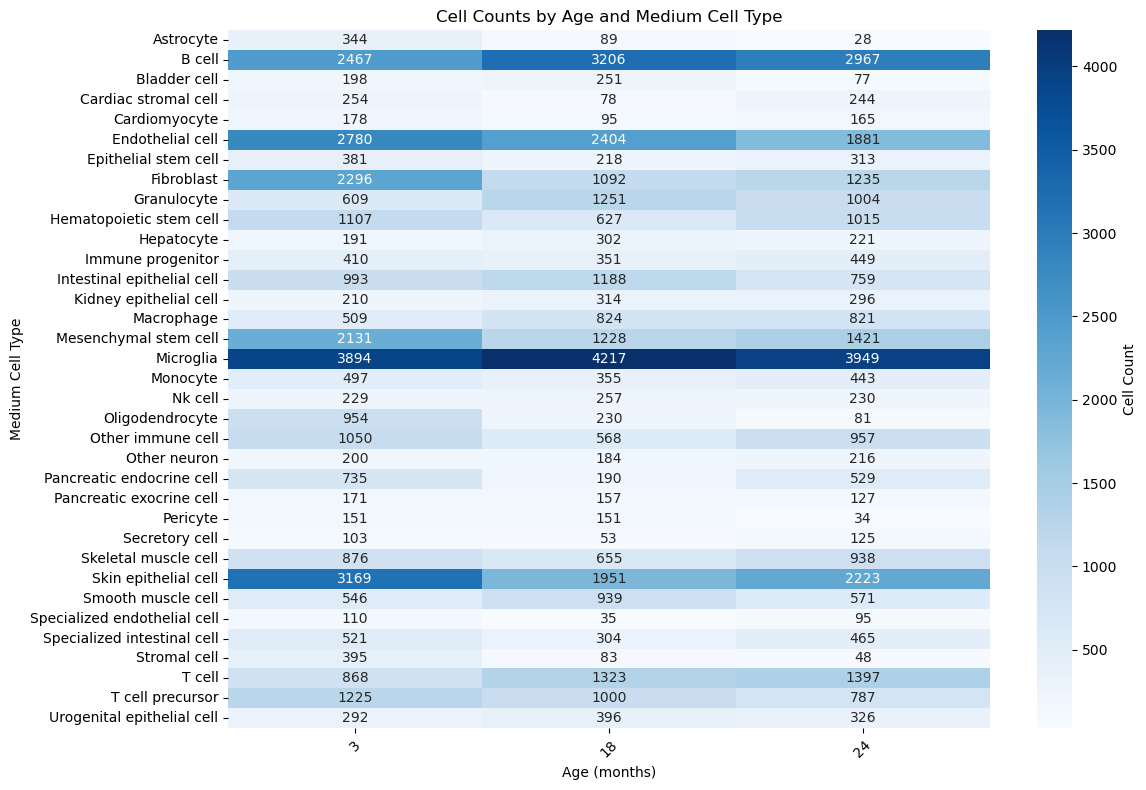

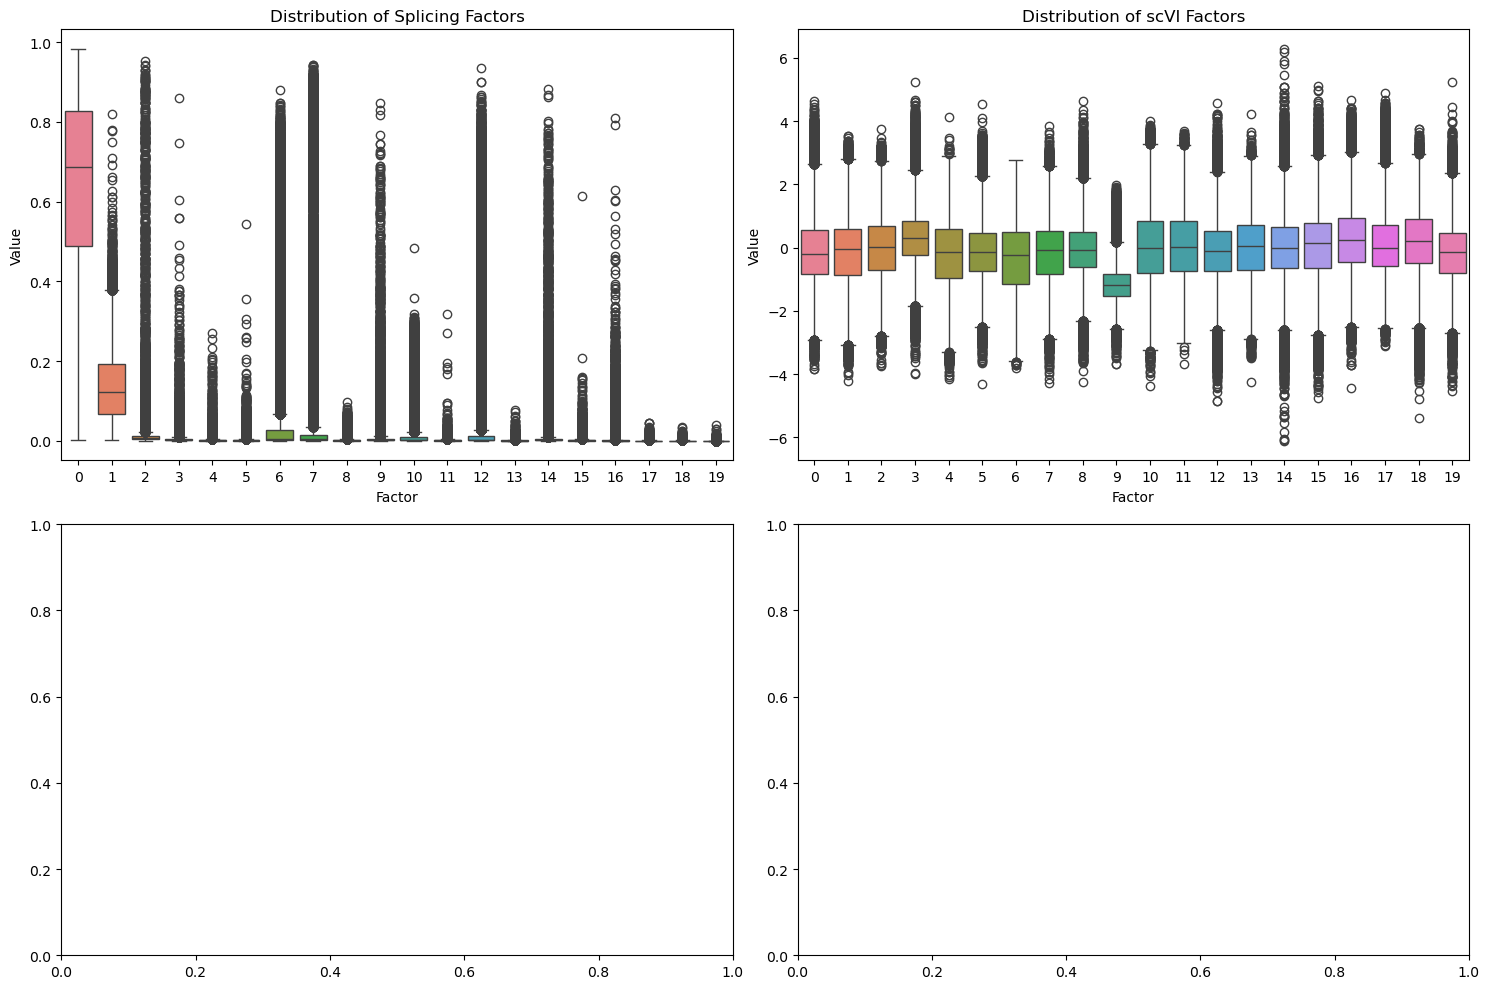

In [9]:
# Run EDA
create_age_celltype_heatmap(splice_adata, paths['output_dir'])
create_factor_boxplots(splice_adata, ge_adata, paths['output_dir'])

## 9. Ridge Regression Analysis

In [10]:
splice_adata.obs["age_numeric"].value_counts()

age_numeric
3     31044
18    26566
24    26437
Name: count, dtype: int64

In [11]:
def run_tissue_ridge_analysis(splice_adata, ge_adata, covariate="medium_cell_type", 
                             alphas=np.logspace(-2, 3, 20)):
    """
    Run ridge regression analysis by tissue/cell type.
    """
    print(f"Running ridge regression analysis by {covariate}...")
    
    # Extract features
    assert all(splice_adata.obs_names == ge_adata.obs_names)
    
    dirichlet_data = splice_adata.obsm["X_PHI"]
    scvi_data = ge_adata.obsm["X_scVI_linear"]
    age = splice_adata.obs['age_numeric'].values
    
    results = {}
    feature_importance_data = []
    
    n_splice_factors = dirichlet_data.shape[1]
    n_scvi_factors = scvi_data.shape[1]
    
    splice_factor_names = [f"SP_{i+1}" for i in range(n_splice_factors)]
    scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
    
    for tissue in tqdm(splice_adata.obs[covariate].unique()):
        mask = (splice_adata.obs[covariate] == tissue).values
        if mask.sum() < 100 or len(np.unique(age[mask])) == 1:
            continue
            
        # Get tissue-specific data
        X_sp = StandardScaler().fit_transform(dirichlet_data[mask])
        X_sc = StandardScaler().fit_transform(scvi_data[mask])
        X_comb = np.hstack([X_sp, X_sc])
        y = age[mask]
        
        # Fit models
        ridge_sp = RidgeCV(alphas=alphas, cv=5).fit(X_sp, y)
        ridge_sc = RidgeCV(alphas=alphas, cv=5).fit(X_sc, y)
        ridge_comb = RidgeCV(alphas=alphas, cv=5).fit(X_comb, y)
        
        # Get R² scores
        r2_sp = ridge_sp.score(X_sp, y)
        r2_sc = ridge_sc.score(X_sc, y)
        r2_comb = ridge_comb.score(X_comb, y)
        
        # Statistical tests
        n = len(y)
        rss_sp = np.sum((y - ridge_sp.predict(X_sp))**2)
        rss_sc = np.sum((y - ridge_sc.predict(X_sc))**2)
        rss_comb = np.sum((y - ridge_comb.predict(X_comb))**2)
        
        # F-tests
        f_vs_sp = ((rss_sp - rss_comb) / n_scvi_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sp = 1 - stats.f.cdf(f_vs_sp, n_scvi_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        f_vs_sc = ((rss_sc - rss_comb) / n_splice_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sc = 1 - stats.f.cdf(f_vs_sc, n_splice_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        results[tissue] = {
            'n_cells': mask.sum(),
            'splice_r2': r2_sp,
            'scvi_r2': r2_sc,
            'combined_r2': r2_comb,
            'p_combined_vs_splice': p_vs_sp,
            'p_combined_vs_scvi': p_vs_sc
        }
        
        # Feature importance
        combined_coefs = ridge_comb.coef_
        splice_coefs = combined_coefs[:n_splice_factors]
        scvi_coefs = combined_coefs[n_splice_factors:]
        
        for i, coef in enumerate(splice_coefs):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Splicing',
                'factor_name': splice_factor_names[i],
                'coefficient': coef,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc
            })
        
        for i, coef in enumerate(scvi_coefs):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Gene_Expression',
                'factor_name': scvi_factor_names[i],
                'coefficient': coef,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc
            })
    
    return results, pd.DataFrame(feature_importance_data)

from scipy import stats
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

def bootstrap_ridge_coefficients(X, y, alphas=np.logspace(-2, 3, 20), n_bootstrap=100):
    """
    Bootstrap Ridge regression to get coefficient confidence intervals.
    """
    n_features = X.shape[1]
    bootstrap_coefs = []
    
    # Fit original model to get best alpha
    ridge = RidgeCV(alphas=alphas, cv=5).fit(X, y)
    best_alpha = ridge.alpha_
    
    # Bootstrap sampling
    for i in range(n_bootstrap):
        # Resample with replacement
        X_boot, y_boot = resample(X, y, random_state=i)
        
        # Fit ridge with best alpha
        ridge_boot = RidgeCV(alphas=[best_alpha], cv=3).fit(X_boot, y_boot)
        bootstrap_coefs.append(ridge_boot.coef_)
    
    bootstrap_coefs = np.array(bootstrap_coefs)
    
    # Calculate confidence intervals (2.5% and 97.5% percentiles)
    ci_lower = np.percentile(bootstrap_coefs, 2.5, axis=0)
    ci_upper = np.percentile(bootstrap_coefs, 97.5, axis=0)
    
    return ridge.coef_, ci_lower, ci_upper, ridge.score(X, y)


def run_tissue_ridge_analysis_with_ci(splice_adata, ge_adata, covariate="medium_cell_type",
                                     alphas=np.logspace(-2, 3, 20), n_bootstrap=50):
    """
    Enhanced ridge regression analysis with confidence intervals.
    """
    print(f"Running ridge regression analysis with CI by {covariate}...")
    
    # Extract features
    assert all(splice_adata.obs_names == ge_adata.obs_names)
    
    dirichlet_data = splice_adata.obsm["X_PHI"]
    scvi_data = ge_adata.obsm["X_scVI_linear"]
    age = splice_adata.obs['age_numeric'].values
    
    results = {}
    feature_importance_data = []
    
    n_splice_factors = dirichlet_data.shape[1]
    n_scvi_factors = scvi_data.shape[1]
    
    splice_factor_names = [f"SP_{i+1}" for i in range(n_splice_factors)]
    scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
    
    for tissue in splice_adata.obs[covariate].unique():
        mask = (splice_adata.obs[covariate] == tissue).values
        if mask.sum() < 100 or len(np.unique(age[mask])) == 1:
            continue
        
        print(f"  Processing {tissue} ({mask.sum()} cells)...")
        
        # Get tissue-specific data
        X_sp = StandardScaler().fit_transform(dirichlet_data[mask])
        X_sc = StandardScaler().fit_transform(scvi_data[mask])
        X_comb = np.hstack([X_sp, X_sc])
        y = age[mask]
        
        # Fit models with confidence intervals
        sp_coef, sp_ci_low, sp_ci_high, r2_sp = bootstrap_ridge_coefficients(X_sp, y, alphas, n_bootstrap)
        sc_coef, sc_ci_low, sc_ci_high, r2_sc = bootstrap_ridge_coefficients(X_sc, y, alphas, n_bootstrap)
        comb_coef, comb_ci_low, comb_ci_high, r2_comb = bootstrap_ridge_coefficients(X_comb, y, alphas, n_bootstrap)
        
        # Statistical tests (same as before)
        ridge_sp = RidgeCV(alphas=alphas, cv=5).fit(X_sp, y)
        ridge_sc = RidgeCV(alphas=alphas, cv=5).fit(X_sc, y)
        ridge_comb = RidgeCV(alphas=alphas, cv=5).fit(X_comb, y)
        
        n = len(y)
        rss_sp = np.sum((y - ridge_sp.predict(X_sp))**2)
        rss_sc = np.sum((y - ridge_sc.predict(X_sc))**2)
        rss_comb = np.sum((y - ridge_comb.predict(X_comb))**2)
        
        f_vs_sp = ((rss_sp - rss_comb) / n_scvi_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sp = 1 - stats.f.cdf(f_vs_sp, n_scvi_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        f_vs_sc = ((rss_sc - rss_comb) / n_splice_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sc = 1 - stats.f.cdf(f_vs_sc, n_splice_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        results[tissue] = {
            'n_cells': mask.sum(),
            'splice_r2': r2_sp,
            'scvi_r2': r2_sc,
            'combined_r2': r2_comb,
            'p_combined_vs_splice': p_vs_sp,
            'p_combined_vs_scvi': p_vs_sc
        }
        
        # Store coefficients with confidence intervals
        # Combined model coefficients
        splice_coefs_comb = comb_coef[:n_splice_factors]
        scvi_coefs_comb = comb_coef[n_splice_factors:]
        splice_ci_low_comb = comb_ci_low[:n_splice_factors]
        splice_ci_high_comb = comb_ci_high[:n_splice_factors]
        scvi_ci_low_comb = comb_ci_low[n_splice_factors:]
        scvi_ci_high_comb = comb_ci_high[n_splice_factors:]
        
        for i, (coef, ci_low, ci_high) in enumerate(zip(splice_coefs_comb, splice_ci_low_comb, splice_ci_high_comb)):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Splicing',
                'factor_name': splice_factor_names[i],
                'coefficient': coef,
                'ci_lower': ci_low,
                'ci_upper': ci_high,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc,
                'significant': ci_low * ci_high > 0  # CI doesn't cross zero
            })
        
        for i, (coef, ci_low, ci_high) in enumerate(zip(scvi_coefs_comb, scvi_ci_low_comb, scvi_ci_high_comb)):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Gene_Expression',
                'factor_name': scvi_factor_names[i],
                'coefficient': coef,
                'ci_lower': ci_low,
                'ci_upper': ci_high,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc,
                'significant': ci_low * ci_high > 0
            })
    
    return results, pd.DataFrame(feature_importance_data)

In [12]:
assert all(splice_adata.obs_names == ge_adata.obs_names)
ge_adata.obs["age_numeric"] = splice_adata.obs["age_numeric"]

In [13]:
# remove 2months old cells from splice_adata.obs["age_numeric"]
splicing_aging = splice_adata[splice_adata.obs["age_numeric"] != 2].copy()
ge_adata_aging = ge_adata[ge_adata.obs["age_numeric"] != 2].copy()
assert all(splicing_aging.obs_names == ge_adata_aging.obs_names)

In [14]:
# Run ridge regression analysis
results, feature_importance_df = run_tissue_ridge_analysis(splicing_aging, ge_adata_aging)

Running ridge regression analysis by medium_cell_type...


100%|██████████| 35/35 [01:05<00:00,  1.87s/it]


In [15]:
# Run analysis with confidence intervals
results_ci, feature_df_ci = run_tissue_ridge_analysis_with_ci(splicing_aging, ge_adata_aging, n_bootstrap=50)

Running ridge regression analysis with CI by medium_cell_type...
  Processing Skin epithelial cell (7343 cells)...
  Processing Other immune cell (2575 cells)...
  Processing Endothelial cell (7065 cells)...
  Processing Cardiomyocyte (438 cells)...
  Processing Smooth muscle cell (2056 cells)...
  Processing Intestinal epithelial cell (2940 cells)...
  Processing Epithelial stem cell (912 cells)...
  Processing Fibroblast (4623 cells)...
  Processing Secretory cell (281 cells)...
  Processing B cell (8640 cells)...
  Processing Granulocyte (2864 cells)...
  Processing T cell (3588 cells)...
  Processing Immune progenitor (1210 cells)...
  Processing Cardiac stromal cell (576 cells)...
  Processing Urogenital epithelial cell (1014 cells)...
  Processing Pancreatic endocrine cell (1454 cells)...
  Processing Nk cell (716 cells)...
  Processing Microglia (12060 cells)...
  Processing T cell precursor (3012 cells)...
  Processing Kidney epithelial cell (820 cells)...
  Processing Skeletal

## 10. Results Visualization

In [16]:
def create_performance_plot(results, output_dir):
    """Create performance comparison plot."""
    # Create summary DataFrame
    summary_data = []
    for tissue, res in results.items():
        summary_data.append({
            'tissue': tissue,
            'n_cells': res['n_cells'],
            'LeafletFA_r2': res['splice_r2'],
            'scVI_r2': res['scvi_r2'],
            'LeafletFA_scVI_r2': res['combined_r2'],
            'p_combined_vs_LeafletFA': res['p_combined_vs_splice'],
            'p_combined_vs_scVI': res['p_combined_vs_scvi']
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # FDR correction
    summary_df["p_combined_vs_scVI_fdr"] = multipletests(
        summary_df["p_combined_vs_scVI"], method="fdr_bh"
    )[1]
    
    # Sort and reshape for plotting
    summary_df_sorted = summary_df.sort_values('LeafletFA_r2', ascending=False)
    
    plot_data = []
    for _, row in summary_df_sorted.iterrows():
        for model in ['LeafletFA', 'scVI', 'LeafletFA_scVI']:
            plot_data.append({
                'tissue': row['tissue'],
                'model': model,
                'r2': row[f'{model}_r2']
            })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    sns.barplot(data=plot_df, x='tissue', y='r2', hue='model', ax=ax, alpha=0.8)
    
    # Add significance markers
    for i, (_, row) in enumerate(summary_df_sorted.iterrows()):
        p_val = row['p_combined_vs_scVI_fdr']
        sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        
        if sig_text:
            combined_r2 = row['LeafletFA_scVI_r2']
            ax.text(i, combined_r2 + 0.02, sig_text, ha='center', va='bottom', 
                   fontweight='bold', fontsize=10)
    
    ax.set_xlabel('Cell Type', fontsize=14)
    ax.set_ylabel('Age Prediction Ridge Regression R²', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(f'{output_dir}/age_prediction_performance.pdf', dpi=300, bbox_inches='tight')
    print(f"Saved plot to {output_dir}/age_prediction_performance.pdf")
    plt.show()
    
    return summary_df

In [17]:
def create_correlation_analysis_with_gene_loadings(splice_adata, ge_adata, output_dir):
    """Create correlation analysis between scVI and LeafletFA factors with top gene loadings."""
    print("Computing factor correlations with gene loading annotations...")
    
    X_PHI = splice_adata.obsm["X_PHI"]
    X_scVI = ge_adata.obsm["X_scVI_linear"]
    scvi_gene_loadings = ge_adata.varm["scVI_linear_gene_loadings"]
    gene_names = ge_adata.var["gene_name"].values
    
    n_scvi_factors = X_scVI.shape[1]
    n_splicing_factors = X_PHI.shape[1]
    
    # Compute correlations
    corr_matrix = np.zeros((n_scvi_factors, n_splicing_factors))
    pval_matrix = np.zeros((n_scvi_factors, n_splicing_factors))
    
    for i in range(n_scvi_factors):
        for j in range(n_splicing_factors):
            rho, pval = spearmanr(X_scVI[:, i], X_PHI[:, j])
            corr_matrix[i, j] = rho
            pval_matrix[i, j] = pval
    
    # FDR correction
    _, pvals_fdr_flat, _, _ = multipletests(pval_matrix.flatten(), method='fdr_bh')
    fdr_matrix = pvals_fdr_flat.reshape(pval_matrix.shape)
    
    # Create significance annotations
    fdr_thresh = 0.05
    rho_thresh = 0.2
    annot_matrix = np.where(
        (fdr_matrix < fdr_thresh) & (np.abs(corr_matrix) > rho_thresh),
        "*", ""
    )
    
    # Create scVI factor labels with top 5 genes
    scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
    scvi_labels_with_genes = []
    gene_loading_summary = []
    
    for i, factor_name in enumerate(scvi_factor_names):
        # Get top 5 genes by absolute loading values
        factor_loadings = scvi_gene_loadings.iloc[:, i].values
        top_gene_indices = np.argsort(-np.abs(factor_loadings))[:5]  # Top 5 genes
        top_genes = gene_names[top_gene_indices]
        top_loadings = factor_loadings[top_gene_indices]
        
        # Create label with top 3 genes for display (to keep labels readable)
        gene_label = f"{factor_name}: {', '.join(top_genes[:5])}"
        scvi_labels_with_genes.append(gene_label)
        
        # Store detailed info for all top 5 genes
        gene_loading_summary.append({
            'Factor': factor_name,
            'Top_Gene_1': top_genes[0],
            'Loading_1': top_loadings[0],
            'Top_Gene_2': top_genes[1],
            'Loading_2': top_loadings[1],
            'Top_Gene_3': top_genes[2],
            'Loading_3': top_loadings[2],
            'Top_Gene_4': top_genes[3],
            'Loading_4': top_loadings[3],
            'Top_Gene_5': top_genes[4],
            'Loading_5': top_loadings[4],
            'Top_3_Display': ', '.join(top_genes[:3]),
            'Top_5_All': ', '.join(top_genes)
        })
    
    splicing_factor_names = [f"SP_{i+1}" for i in range(n_splicing_factors)]
    
    # Create correlation DataFrame
    corr_df = pd.DataFrame(
        corr_matrix,
        index=scvi_labels_with_genes,
        columns=splicing_factor_names
    )
    
    # Create clustermap with PRGn colormap
    plt.figure(figsize=(8,6))  # Increased size for gene labels
    
    g = sns.clustermap(
        corr_df,
        cmap="PRGn",
        center=0,
        linewidths=0.3,
        linecolor="white",
        xticklabels=True,
        yticklabels=True,
        annot=annot_matrix,
        fmt='',
        annot_kws={'size': 8, 'color': 'black', 'weight': 'bold'},
        figsize=(8,6),
        cbar_kws={'label': 'Spearman Correlation', 'shrink': 0.8},
        col_cluster=False,  # Don't cluster columns (keep SP order)
        row_cluster=True   # Cluster rows (scVI factors)
    )
    
    g.ax_heatmap.set_xlabel("LeafletFA Splicing Programs", fontsize=14, fontweight='bold')
    g.ax_heatmap.set_ylabel("scVI Latent Factors (Top Genes)", fontsize=14, fontweight='bold')
    
    # Adjust label formatting
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=10)
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)
    
    # Add significance legend
    legend_text = f"* Significant: FDR < {fdr_thresh}, |ρ| > {rho_thresh}"
    g.fig.text(0.02, 0.98, legend_text, fontsize=11, style='italic',
               verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", 
               facecolor="lightgray", alpha=0.7))
    
    # Save the plot
    output_path = f"{output_dir}/scVI_leafletFA_correlation_with_gene_loadings.pdf"
    g.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    # Save correlation matrix with gene annotations
    corr_df.to_csv(f"{output_dir}/scVI_leafletFA_correlations_with_gene_loadings.csv")
    
    # Save detailed gene loading summary
    gene_loading_df = pd.DataFrame(gene_loading_summary)
    gene_loading_df.to_csv(f"{output_dir}/scVI_top5_gene_loadings_summary.csv", index=False)
    
    print(f"Saved correlation analysis with gene loadings to: {output_path}")
    print(f"Saved detailed gene loading summary to: {output_dir}/scVI_top5_gene_loadings_summary.csv")
    
    # Print summary of top genes
    print("\nTop 5 gene loadings for each scVI factor:")
    for i, summary in enumerate(gene_loading_summary):
        print(f"  {summary['Factor']}: {summary['Top_5_All']}")
        if i >= 9:  # Show first 10 factors
            remaining = len(gene_loading_summary) - 10
            if remaining > 0:
                print(f"  ... and {remaining} more factors (see CSV for complete list)")
            break
    
    return corr_df, gene_loading_df

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/age_prediction_performance.pdf


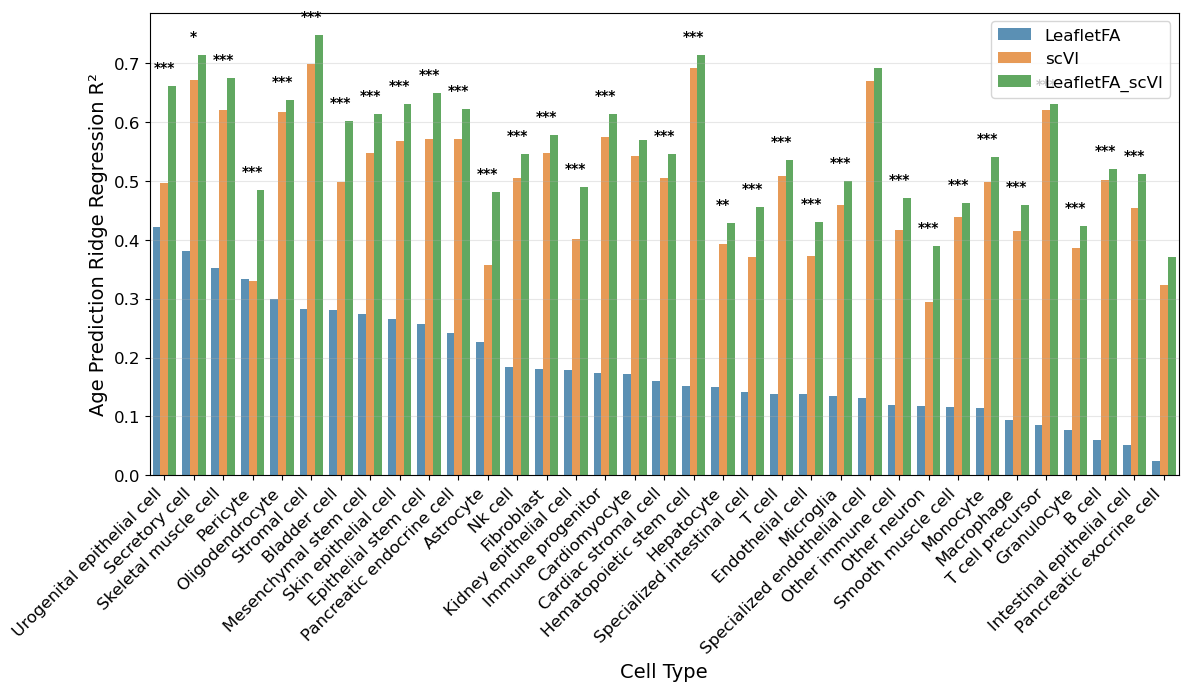

In [18]:
# Run visualizations
summary_df = create_performance_plot(results, paths['output_dir'])

In [19]:
#sc.pl.umap(ge_adata, color=[SCVI_CLUSTERS_KEY])
#zs = [f"Z_{i}" for i in 20]
#sc.pl.umap(ge_adata, color=zs, ncols=3)

In [20]:
ge_adata_aging, splicing_aging

(AnnData object with n_obs × n_vars = 84047 × 2482
     obs: 'cell_id', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'tissue', 'dataset', 'batch', 'subtissue_clean', 'broad_cell_type', 'cell_id_index', 'specific_cell_type', 'medium_cell_type', 'cell_name', 'library_size', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_is_rRNA', 'log1p_total_counts_is_rRNA', 'pct_counts_is_rRNA', 'nuclear_score_log_norm', 'nuclear_ratio_log_norm', 'nuclear_rrna_log_norm', 'nuclear_class_log_norm', 'nuclear_score_predicted_log_norm_tms', 'nuclear_ratio_predicted_log_norm_tms', 'nuclear_rrna_predicted_log_norm_tms', 'nuclear_class_predicted_log_norm_tms', 'AgingScore_pos', 'AgingScore_neg', 'AgingScore_unweighted', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'age_numeric'
     var: 'index', 'gene_name', 'gene_id', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'transcript_biotypes', 'is_rRNA', 'n_cells_by_counts', 'mean_counts'

Computing factor correlations with gene loading annotations...


<Figure size 800x600 with 0 Axes>

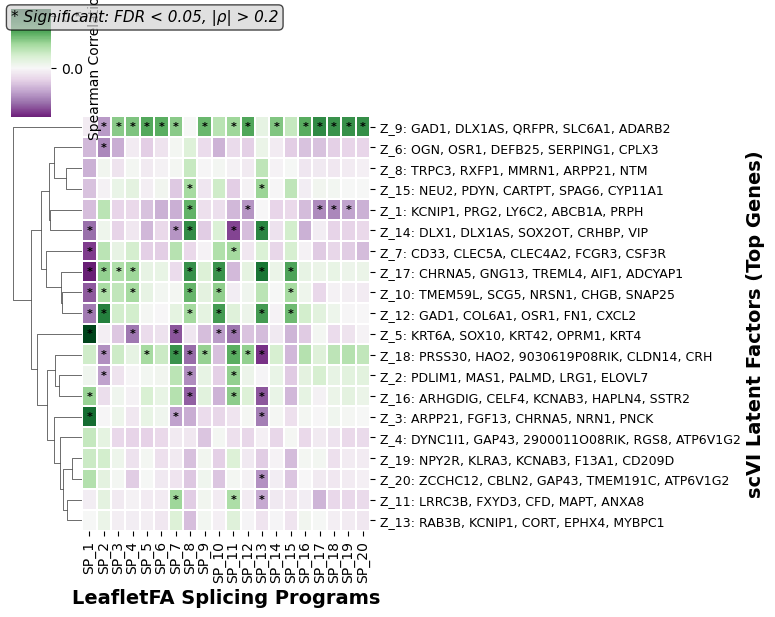

Saved correlation analysis with gene loadings to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/scVI_leafletFA_correlation_with_gene_loadings.pdf
Saved detailed gene loading summary to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/scVI_top5_gene_loadings_summary.csv

Top 5 gene loadings for each scVI factor:
  Z_1: KCNIP1, PRG2, LY6C2, ABCB1A, PRPH
  Z_2: PDLIM1, MAS1, PALMD, LRG1, ELOVL7
  Z_3: ARPP21, FGF13, CHRNA5, NRN1, PNCK
  Z_4: DYNC1I1, GAP43, 2900011O08RIK, RGS8, ATP6V1G2
  Z_5: KRT6A, SOX10, KRT42, OPRM1, KRT4
  Z_6: OGN, OSR1, DEFB25, SERPING1, CPLX3
  Z_7: CD33, CLEC5A, CLEC4A2, FCGR3, CSF3R
  Z_8: TRPC3, RXFP1, MMRN1, ARPP21, NTM
  Z_9: GAD1, DLX1AS, QRFPR, SLC6A1, ADARB2
  Z_10: TMEM59L, SCG5, NRSN1, CHGB, SNAP25
  ... and 10 more factors (see CSV for com

In [21]:
# Replace your correlation analysis call with:
corr_df, gene_loading_df = create_correlation_analysis_with_gene_loadings(
    splicing_aging, ge_adata_aging, paths['output_dir']
)

In [22]:
def create_ridge_coefficients_clustermap(feature_importance_df, splice_adata, output_dir):
    """Create clustermap of ridge coefficients by cell type and factor."""
    print("Creating ridge coefficients clustermap...")
    
    # Pivot the data to create coefficient matrix
    coef_matrix = feature_importance_df.pivot_table(
        index='cell_type',
        columns='factor_name', 
        values='coefficient',
        fill_value=0
    )
    
    # Create mapping from cell_type to broad_cell_type
    cell_type_mapping = splice_adata.obs[['medium_cell_type', 'broad_cell_type']].drop_duplicates()
    cell_type_mapping = cell_type_mapping.set_index('medium_cell_type')['broad_cell_type'].to_dict()
    
    # Get cell counts for each medium cell type
    cell_counts = splice_adata.obs['medium_cell_type'].value_counts().to_dict()
    
    # Create consistent color palette for broad cell types
    unique_broad = splice_adata.obs["broad_cell_type"].unique()
    palette = sns.color_palette("tab20", len(unique_broad))
    palette_dict = dict(zip(unique_broad, palette))
    
    # Create row colors based on broad_cell_type
    broad_cell_types = [cell_type_mapping.get(ct, 'Unknown') for ct in coef_matrix.index]
    row_colors = pd.Series([palette_dict.get(bct, (0.5, 0.5, 0.5)) for bct in broad_cell_types], 
                          index=coef_matrix.index, name='Broad Cell Type')
    
    # Update row labels to include cell counts
    new_row_labels = []
    for ct in coef_matrix.index:
        count = cell_counts.get(ct, 0)
        new_row_labels.append(f"{ct} ({count})")
    
    # Create a copy of the matrix with updated row labels
    coef_matrix_with_counts = coef_matrix.copy()
    coef_matrix_with_counts.index = new_row_labels
    
    # Update row_colors index to match
    row_colors.index = new_row_labels
    
    # Get factor names and separate SP and Z factors
    all_factors = coef_matrix_with_counts.columns.tolist()
    sp_factors = sorted([f for f in all_factors if f.startswith('SP_')], 
                       key=lambda x: int(x.split('_')[1]))
    z_factors = sorted([f for f in all_factors if f.startswith('Z_')], 
                      key=lambda x: int(x.split('_')[1]))
    
    # Create ordered factor list: SP_1, SP_2, ..., Z_1, Z_2, ...
    ordered_factors = sp_factors + z_factors
    
    # Reorder columns according to our desired order
    coef_matrix_ordered = coef_matrix_with_counts[ordered_factors]
    
    # Create figure
    plt.figure(figsize=(16, 10))
    
    # Create clustermap
    g = sns.clustermap(
        coef_matrix_ordered,
        cmap="PRGn",
        center=0,
        linewidths=0.5,
        linecolor="white",
        xticklabels=True,
        yticklabels=True,
        figsize=(18, 12),  # Increased width for color bar
        cbar_kws={'label': 'Ridge Coefficient', 'shrink': 0.8},
        col_cluster=False,  # Don't cluster columns (keep factor order)
        row_cluster=True,   # Cluster rows (cell types)
        row_colors=row_colors,  # Add broad cell type colors
        dendrogram_ratio=0.1,  # Make dendrograms smaller
        colors_ratio=0.03  # Width of the color bar
    )
    
    # Customize the plot
    g.ax_heatmap.set_xlabel("Factors (SP: Splicing Programs, Z: scVI Latent Factors)", 
                           fontsize=14, fontweight='bold')
    g.ax_heatmap.set_ylabel("Cell Types", fontsize=14, fontweight='bold')
    
    # Rotate and adjust tick labels
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=10)
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=10)
    
    # Add vertical line to separate SP and Z factors
    n_sp_factors = len(sp_factors)
    g.ax_heatmap.axvline(x=n_sp_factors-0.5, color='black', linewidth=2, alpha=0.8)
    
    # Add text annotations to distinguish factor types
    g.ax_heatmap.text(n_sp_factors/2 - 0.5, -1.5, 'Splicing Programs', 
                     ha='center', va='top', fontsize=12, fontweight='bold')
    g.ax_heatmap.text(n_sp_factors + len(z_factors)/2 - 0.5, -1.5, 'Gene Expression', 
                     ha='center', va='top', fontsize=12, fontweight='bold')
    
    # Create custom legend for broad cell types (only show types that appear in the clustermap)
    from matplotlib.patches import Patch
    broad_types_in_plot = list(set(broad_cell_types))
    legend_elements = [Patch(facecolor=palette_dict.get(bct, (0.5, 0.5, 0.5)), label=bct) 
                      for bct in sorted(broad_types_in_plot)]
    
    # Add legend for broad cell types
    g.ax_heatmap.legend(handles=legend_elements, 
                       title='Broad Cell Type',
                       bbox_to_anchor=(1.05, 1), 
                       loc='upper left',
                       frameon=True,
                       fancybox=True,
                       shadow=True)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Save the plot
    output_path = f"{output_dir}/ridge_coefficients_clustermap.pdf"
    g.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    # Save the coefficient matrix
    coef_matrix_ordered.to_csv(f"{output_dir}/ridge_coefficients_matrix.csv")
    
    # Save additional info about broad cell types
    broad_cell_type_info = pd.DataFrame({
        'medium_cell_type': coef_matrix.index,  # Original names without counts
        'medium_cell_type_with_counts': new_row_labels,
        'broad_cell_type': broad_cell_types,
        'cell_count': [cell_counts.get(ct, 0) for ct in coef_matrix.index],
        'color': [palette_dict.get(bct, (0.5, 0.5, 0.5)) for bct in broad_cell_types]
    })
    broad_cell_type_info.to_csv(f"{output_dir}/broad_cell_type_colors.csv", index=False)
    
    print(f"Saved ridge coefficients clustermap to: {output_path}")
    print(f"Saved coefficient matrix to: {output_dir}/ridge_coefficients_matrix.csv")
    print(f"Saved broad cell type colors to: {output_dir}/broad_cell_type_colors.csv")
    
    # Print summary statistics
    print(f"\nClustermap Summary:")
    print(f"  Cell types: {len(coef_matrix_ordered.index)}")
    print(f"  Broad cell types in plot: {len(set(broad_cell_types))}")
    print(f"  Total broad cell types available: {len(unique_broad)}")
    print(f"  Splicing factors (SP): {len(sp_factors)}")
    print(f"  Gene expression factors (Z): {len(z_factors)}")
    print(f"  Total factors: {len(ordered_factors)}")
    print(f"  Coefficient range: {coef_matrix_ordered.min().min():.3f} to {coef_matrix_ordered.max().max():.3f}")
    
    # Print broad cell type distribution
    print(f"\nBroad cell type distribution in clustermap:")
    broad_type_counts = pd.Series(broad_cell_types).value_counts()
    for bct, count in broad_type_counts.items():
        total_cells = sum([cell_counts.get(ct, 0) for ct, bct_mapped in cell_type_mapping.items() if bct_mapped == bct and ct in coef_matrix.index])
        print(f"  {bct}: {count} medium cell types, {total_cells} total cells")
    
    # Show top positive and negative coefficients
    coef_flat = coef_matrix_ordered.stack().reset_index()
    coef_flat.columns = ['cell_type', 'factor', 'coefficient']
    
    print(f"\nTop 5 positive coefficients:")
    top_pos = coef_flat.nlargest(5, 'coefficient')
    for _, row in top_pos.iterrows():
        print(f"  {row['cell_type']} - {row['factor']}: {row['coefficient']:.3f}")
    
    print(f"\nTop 5 negative coefficients:")
    top_neg = coef_flat.nsmallest(5, 'coefficient')
    for _, row in top_neg.iterrows():
        print(f"  {row['cell_type']} - {row['factor']}: {row['coefficient']:.3f}")
    
    return coef_matrix_ordered, g

Creating ridge coefficients clustermap...


<Figure size 1600x1000 with 0 Axes>

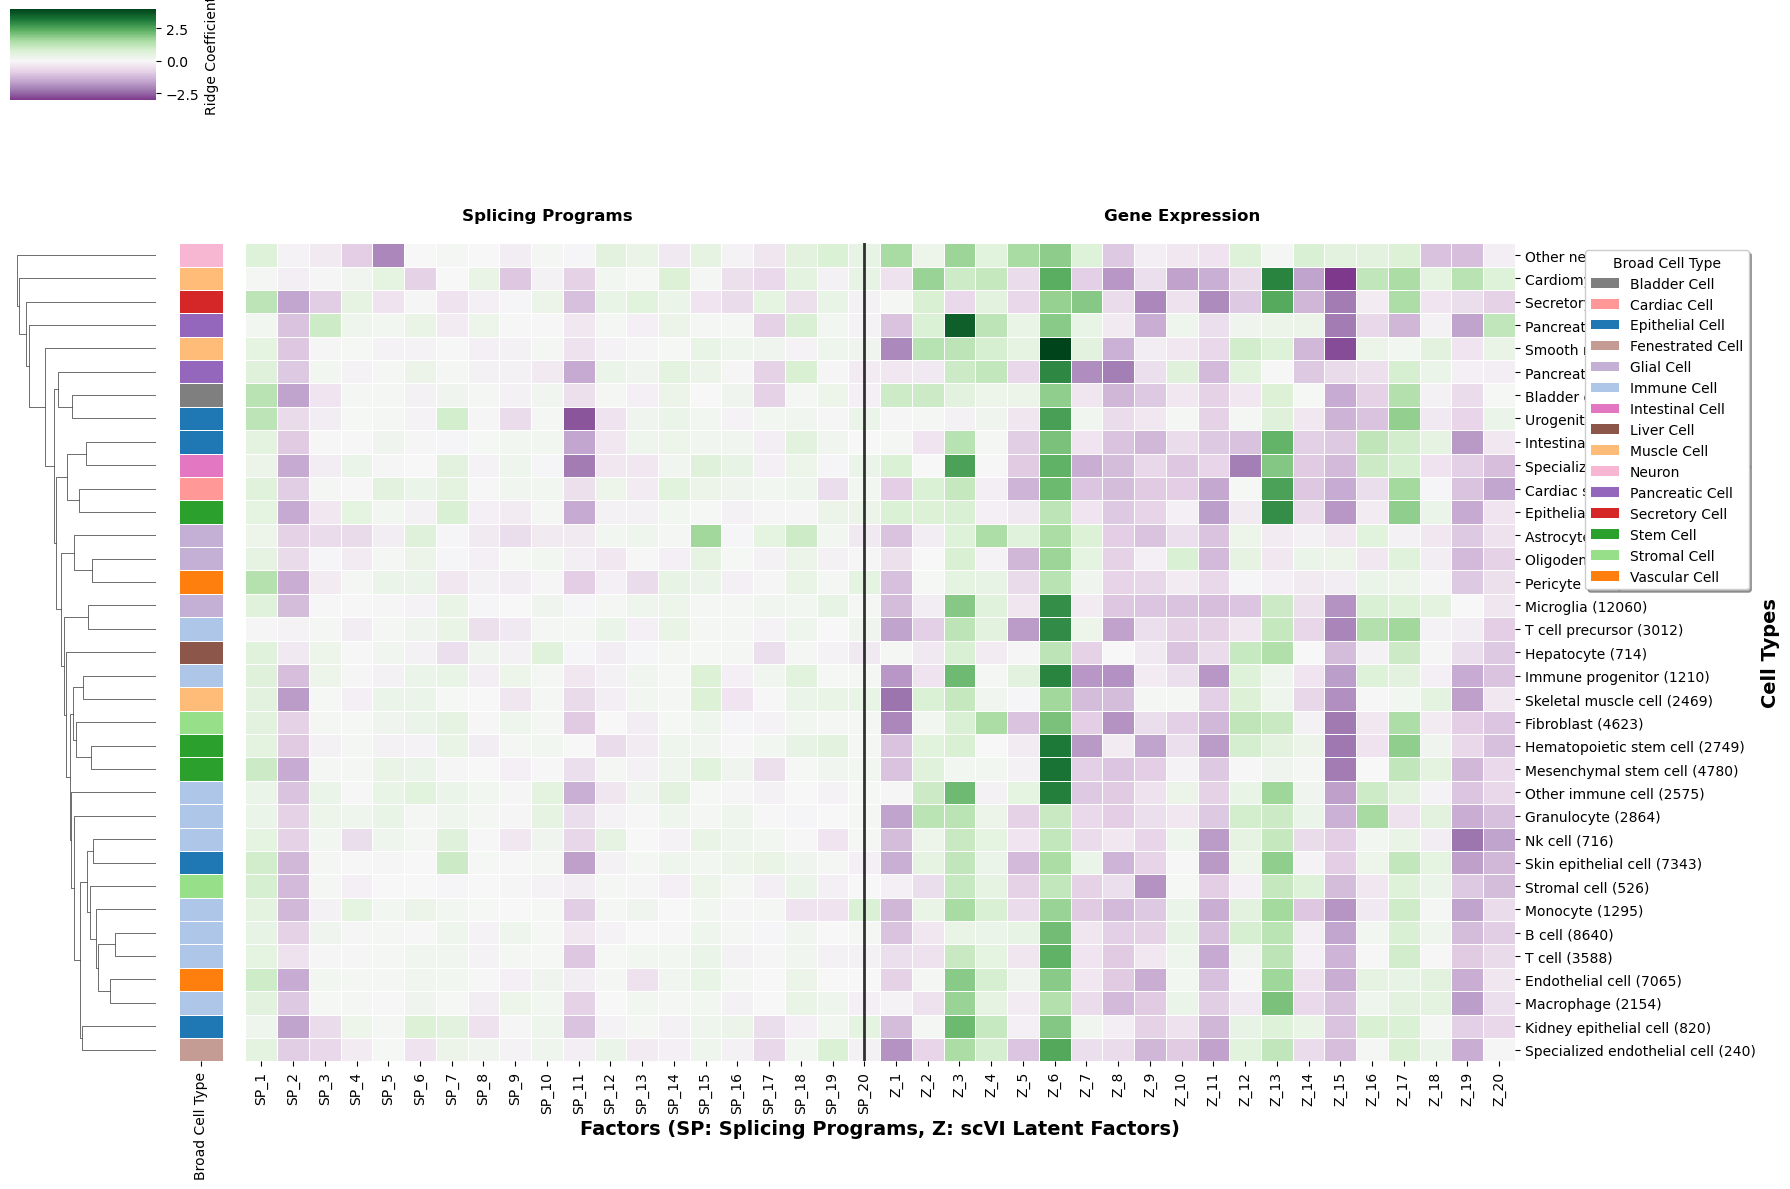

Saved ridge coefficients clustermap to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/ridge_coefficients_clustermap.pdf
Saved coefficient matrix to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/ridge_coefficients_matrix.csv
Saved broad cell type colors to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/broad_cell_type_colors.csv

Clustermap Summary:
  Cell types: 35
  Broad cell types in plot: 15
  Total broad cell types available: 15
  Splicing factors (SP): 20
  Gene expression factors (Z): 20
  Total factors: 40
  Coefficient range: -3.002 to 3.982

Broad cell type distribution in clustermap:
  Immune Cell: 9 medium cell types, 26054 total cells
  Epithelial 

In [23]:
coef_matrix, clustermap_obj = create_ridge_coefficients_clustermap(
    feature_importance_df, splice_adata, paths['output_dir']
)

In [24]:
# rename columns ge_adata.varm["scVI_linear_gene_loadings"] to be Z_1 to Z_20 
ge_adata.varm["scVI_linear_gene_loadings"].columns = [f"Z_{i}" for i in range(1, 21)]

##  Visualize Factor Activity in a Given Cell Type

In [25]:
def plot_factor_activity_by_age(
    adata,
    factor_matrix_key,
    factor_prefix,
    factor_index,
    cell_type_name,
    obs_col="medium_cell_type",
    age_col="age_numeric"
):
    """
    Plot a specific factor's activity across ages within a selected cell type.
    Adds cell counts to x-axis labels and adjusts color if factor is gene expression.
    """
    # Filter to the target cell type
    mask = adata.obs[obs_col] == cell_type_name
    if mask.sum() == 0:
        print(f"No cells found for cell type: {cell_type_name}")
        return

    # Get data
    factor_values = adata.obsm[factor_matrix_key][mask, factor_index]
    ages = adata.obs.loc[mask, age_col]

    # Build DataFrame
    factor_label = f"{factor_prefix}_{factor_index + 1}"
    df = pd.DataFrame({
        factor_label: factor_values,
        "age": ages
    })

    # Compute counts and relabel x-axis
    age_counts = df["age"].value_counts().sort_index()
    age_labels = [f"{int(age)} (n={count})" for age, count in age_counts.items()]
    age_order = age_counts.index.tolist()

    # Choose color palette
    if factor_prefix.upper().startswith("Z"):
        violin_color = "#4C72B0"  # blue for gene expression
    else:
        violin_color = "#55A868"  # green for splicing

    # Plot
    plt.figure(figsize=(6, 4))
    sns.violinplot(
        data=df, x="age", y=factor_label,
        order=age_order,
        inner="box", linewidth=1, color=violin_color
    )
    sns.stripplot(
        data=df, x="age", y=factor_label,
        order=age_order,
        color="black", alpha=0.3, jitter=0.2, size=2
    )

    # Set custom x-tick labels
    plt.xticks(ticks=range(len(age_labels)), labels=age_labels, rotation=0)
    plt.title(f"{factor_label} Activity in {cell_type_name} by Age", fontsize=13)
    plt.xlabel("Age (with cell counts)")
    plt.ylabel("Factor Activity")
    plt.tight_layout()
    plt.show()

In [26]:
splicing_aging, ge_adata_aging

(AnnData object with n_obs × n_vars = 84047 × 35197
     obs: 'cell_id_index', 'age', 'cell_ontology_class', 'donor_id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'broad_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'AgingScore_unweighted', 'AgingScore_pos', 'AgingScore_neg', 'nuclear_ratio_log_norm', 'age_numeric', 'age_group', 'perplexity', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'total_counts', 'nuclear_class_log_norm', 'nuclear_score_log_norm'
     var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'n_cells_detecte

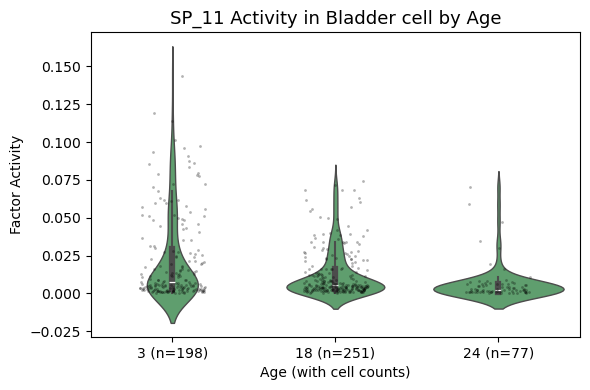

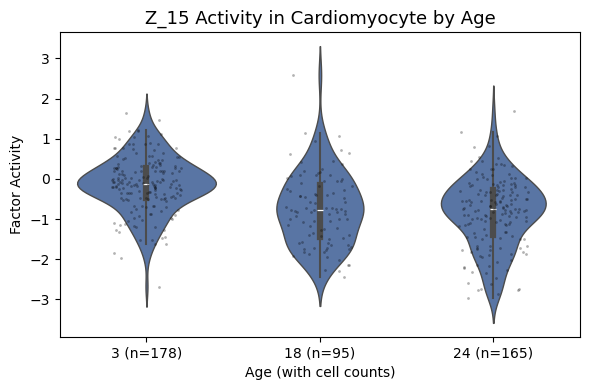

In [27]:
plot_factor_activity_by_age(splicing_aging, "X_PHI", "SP", factor_index=10, cell_type_name="Bladder cell")
plot_factor_activity_by_age(ge_adata_aging, "X_scVI_linear", "Z", factor_index=14, cell_type_name="Cardiomyocyte")

## Correlation Between SP and Z Factors in a Given Cell Type

In [28]:
def plot_sp_z_correlation(splice_adata, ge_adata, sp_index, z_index, cell_type_name, obs_col="medium_cell_type"):
    """
    Scatter plot of SP and Z factor activity for a specific cell type.
    """
    # Add option to plot all cells 
    # Make hexbin version to group points into high density regions
    mask = splice_adata.obs[obs_col] == cell_type_name
    sp_val = splice_adata.obsm["X_PHI"][mask, sp_index]
    z_val = ge_adata.obsm["X_scVI_linear"][mask, z_index]
    
    df = pd.DataFrame({
        f"SP_{sp_index+1}": sp_val,
        f"Z_{z_index+1}": z_val
    })

    corr = np.corrcoef(sp_val, z_val)[0, 1]
    
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=f"SP_{sp_index+1}", y=f"Z_{z_index+1}", data=df, s=20, alpha=0.7, edgecolor='black')
    plt.title(f"{cell_type_name}: SP_{sp_index+1} vs Z_{z_index+1}\nPearson r = {corr:.2f}")
    plt.tight_layout()
    plt.show()

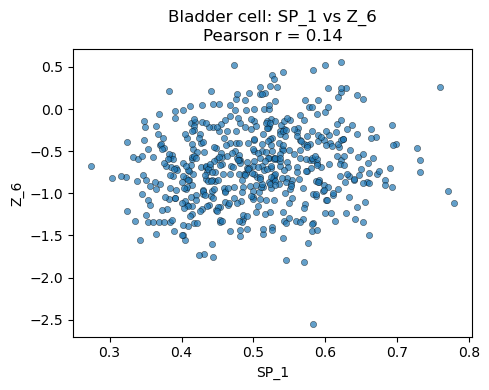

In [29]:
plot_sp_z_correlation(splice_adata, ge_adata, sp_index=0, z_index=5, cell_type_name="Bladder cell")

In [30]:
from scipy import stats

def create_factor_barplot_summary(feature_importance_df, output_dir):
    """
    Publication-ready bar plot showing mean coefficients with error bars
    and annotations for consistency.
    """
    print("🔍 Creating factor summary barplot...")
    
    # Pivot to wide format
    coef_matrix = feature_importance_df.pivot_table(
        index='cell_type',
        columns='factor_name',
        values='coefficient',
        fill_value=0
    )
    
    # Calculate stats
    factor_means = coef_matrix.mean()
    factor_stds = coef_matrix.std()
    
    # Updated consistency: proportion with strong effects (>0.5 or <-0.5) in same direction
    factor_consistency = coef_matrix.apply(lambda x: max((x > 0.5).sum(), (x < -0.5).sum()) / len(x))
    
    # Separate SP and Z factors
    sp_factors = sorted([f for f in factor_means.index if f.startswith("SP_")], 
                       key=lambda x: int(x.split("_")[1]))
    z_factors = sorted([f for f in factor_means.index if f.startswith("Z_")], 
                      key=lambda x: int(x.split("_")[1]))
    
    # Create subplot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 11), sharex=False)
    
    # SP factors (LeafletFA) - Blue
    sp_means = factor_means[sp_factors]
    sp_stds = factor_stds[sp_factors]
    sp_consistency = factor_consistency[sp_factors]
    
    bars1 = ax1.bar(range(len(sp_factors)), sp_means, yerr=sp_stds, 
                    capsize=5, alpha=0.8, color='#1f77b4', edgecolor='black',
                    width=0.7, linewidth=1.5)
    ax1.set_xticks(range(len(sp_factors)))
    ax1.set_xticklabels([f.replace('SP_', '') for f in sp_factors], fontsize=14)
    ax1.set_ylabel('Mean Coefficient ± SD\nAcross Cell Types', fontweight='bold', fontsize=16)
    ax1.set_title('LeafletFA Splicing Programs - Aging Association', fontweight='bold', fontsize=18)
    ax1.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='both', which='major', labelsize=14)
    
    # Add consistency annotations
    for i, (bar, consistency) in enumerate(zip(bars1, sp_consistency)):
        height = bar.get_height()
        if consistency > 0.3:  # Show if >30% have strong effects
            ax1.annotate(f'{consistency:.0%}',
                        xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 10 if height >= 0 else -25),
                        textcoords="offset points",
                        ha='center', va='bottom' if height >= 0 else 'top',
                        fontsize=13, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.9, edgecolor='gray'))
    
    # Z factors (scVI) - Orange  
    z_means = factor_means[z_factors]
    z_stds = factor_stds[z_factors]
    z_consistency = factor_consistency[z_factors]
    
    bars2 = ax2.bar(range(len(z_factors)), z_means, yerr=z_stds,
                    capsize=5, alpha=0.8, color='#ff7f0e', edgecolor='black',
                    width=0.7, linewidth=1.5)
    ax2.set_xticks(range(len(z_factors)))
    ax2.set_xticklabels([f.replace('Z_', '') for f in z_factors], fontsize=14)
    ax2.set_xlabel('Factor Number', fontweight='bold', fontsize=16)
    ax2.set_ylabel('Mean Coefficient ± SD\nAcross Cell Types', fontweight='bold', fontsize=16)
    ax2.set_title('scVI Gene Expression Factors - Aging Association', fontweight='bold', fontsize=18)
    ax2.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='both', which='major', labelsize=14)
    
    # Add consistency annotations
    for i, (bar, consistency) in enumerate(zip(bars2, z_consistency)):
        height = bar.get_height()
        if consistency > 0.3:  # Show if >30% have strong effects
            ax2.annotate(f'{consistency:.0%}',
                        xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 10 if height >= 0 else -25),
                        textcoords="offset points",
                        ha='center', va='bottom' if height >= 0 else 'top',
                        fontsize=13, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.9, edgecolor='gray'))
    
    # Add note about consistency
    fig.text(0.02, 0.02, 'Consistency %: Proportion with strong effects (>|0.5|) in same direction (>30% shown)', 
             fontsize=12, style='italic', alpha=0.7)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    
    # Save
    output_path = f"{output_dir}/factor_aging_barplot_summary.pdf"
    print(f"📁 Saving to: {output_path}")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Done! Consistency = % of cell types with strong effects (>|0.5|) in same direction")


🔍 Creating factor summary barplot...
📁 Saving to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/factor_aging_barplot_summary.pdf


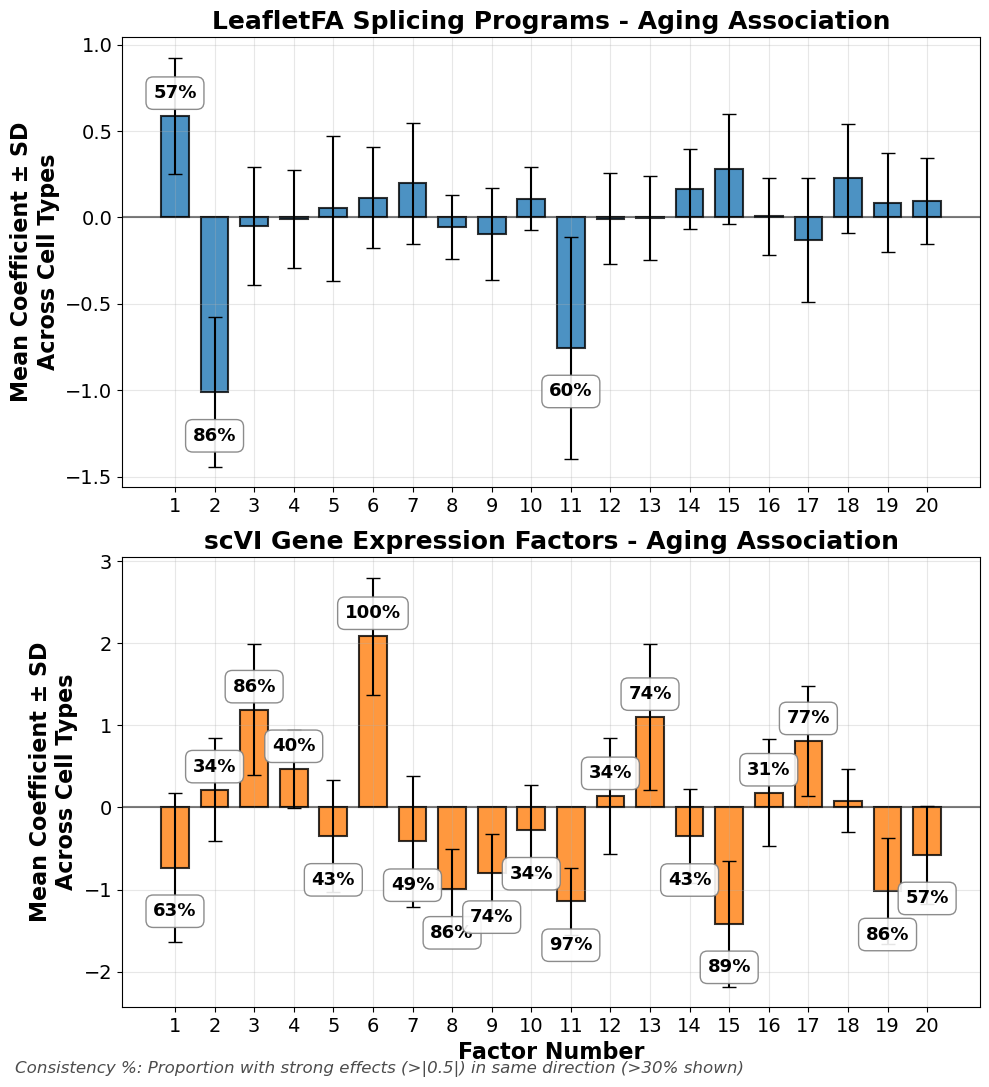

✅ Done! Consistency = % of cell types with strong effects (>|0.5|) in same direction


In [31]:
# Example usage:
create_factor_barplot_summary(feature_importance_df, paths['output_dir'])

In [32]:
def create_forest_plot_single_celltype(feature_df, cell_type, output_dir, top_n_factors=10, figsize=(4, 4)):
    """Create a simple forest plot for a single cell type."""
    
    # Filter and get top factors
    ct_data = feature_df[feature_df['cell_type'] == cell_type].copy()
    ct_data = ct_data.nlargest(top_n_factors, 'abs_coefficient').sort_values('coefficient')
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    colors = {'Splicing': '#1f77b4', 'Gene_Expression': '#ff7f0e'}
    
    for i, (_, row) in enumerate(ct_data.iterrows()):
        ax.errorbar(row['coefficient'], i, 
                   xerr=[[row['coefficient'] - row['ci_lower']], [row['ci_upper'] - row['coefficient']]], 
                   fmt='o', color=colors[row['factor_type']], capsize=3, markersize=6, alpha=0.8)
        
        factor_label = row['factor_name']
        ax.text(row['coefficient'], i, f"  {factor_label}", va='center', 
               ha='left' if row['coefficient'] >= 0 else 'right', fontsize=10)
    
    # Format
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Ridge Regression Coefficient ± 95% CI', fontweight='bold', fontsize=11)
    ax.set_ylabel('Top Factors', fontweight='bold', fontsize=11)
    ax.set_title(cell_type, fontweight='bold', fontsize=12)
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=12)
    ax.grid(True, alpha=0.3, axis='x')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors['Splicing'], label='LeafletFA'),
                      Patch(facecolor=colors['Gene_Expression'], label='scVI')]
    ax.legend(handles=legend_elements, loc='best', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/forest_plot_{cell_type.replace(' ', '_').replace('/', '_')}.pdf", 
                dpi=300, bbox_inches='tight')
    print(f"Saved file to {output_dir}/forest_plot_{cell_type.replace(' ', '_').replace('/', '_')}.pdf")
    plt.show()

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Skin_epithelial_cell.pdf


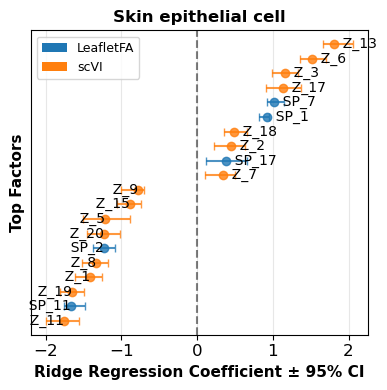

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Other_immune_cell.pdf


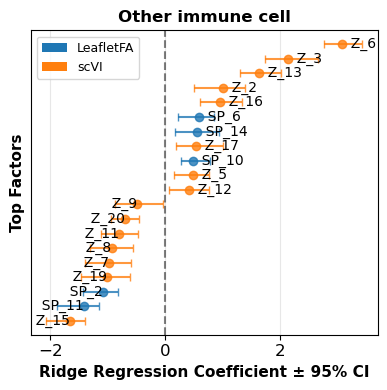

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Endothelial_cell.pdf


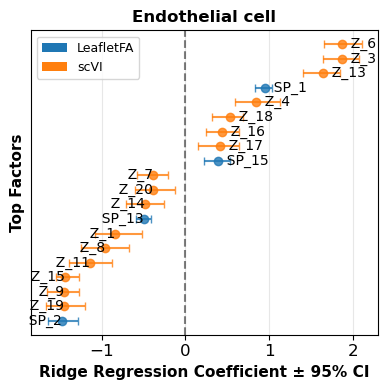

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Cardiomyocyte.pdf


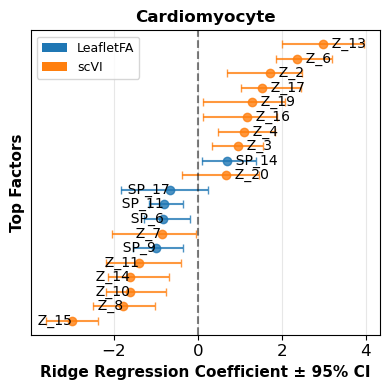

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Smooth_muscle_cell.pdf


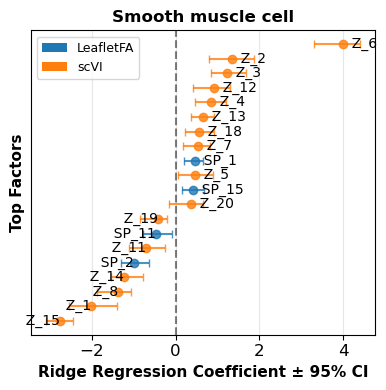

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Intestinal_epithelial_cell.pdf


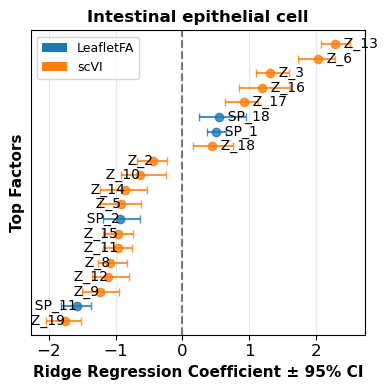

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Epithelial_stem_cell.pdf


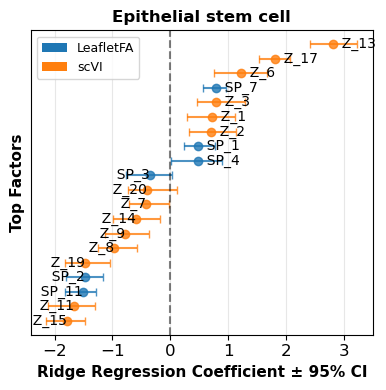

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Fibroblast.pdf


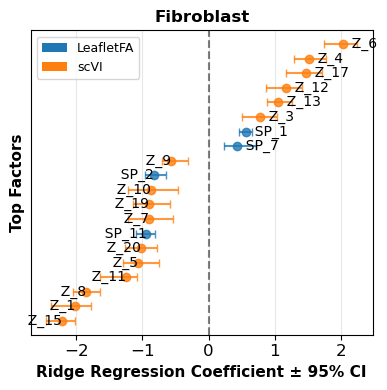

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Secretory_cell.pdf


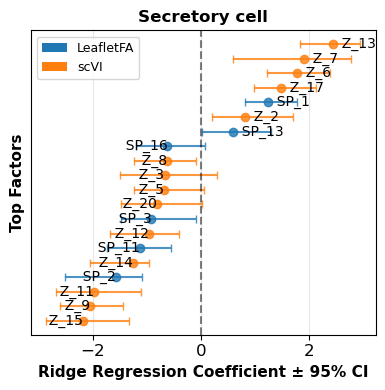

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_B_cell.pdf


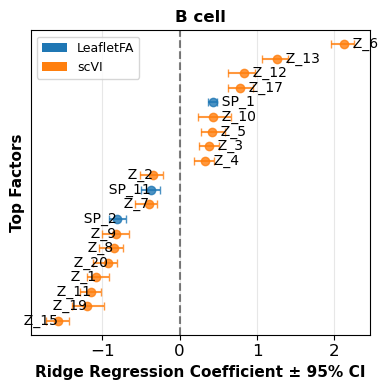

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Granulocyte.pdf


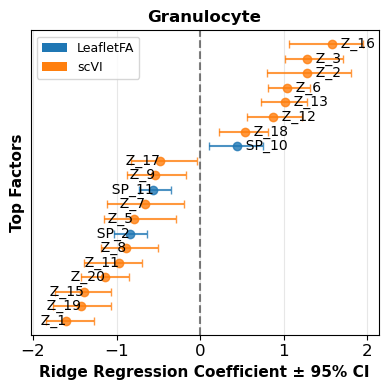

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_T_cell.pdf


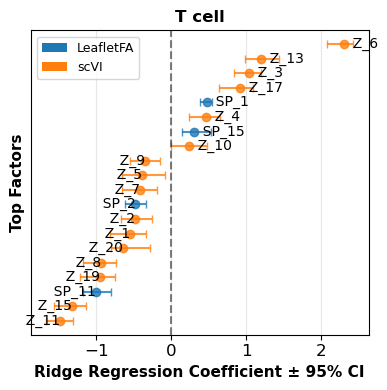

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Immune_progenitor.pdf


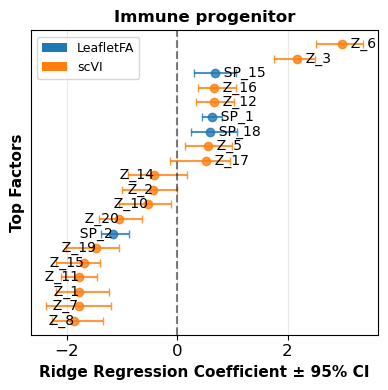

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Cardiac_stromal_cell.pdf


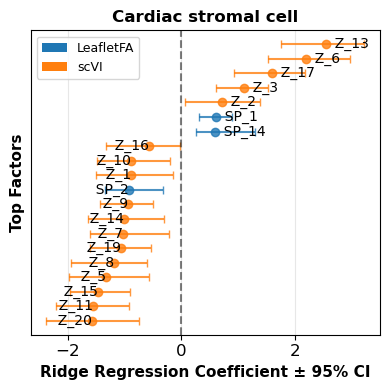

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Urogenital_epithelial_cell.pdf


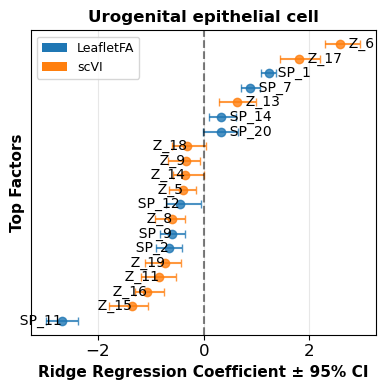

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Pancreatic_endocrine_cell.pdf


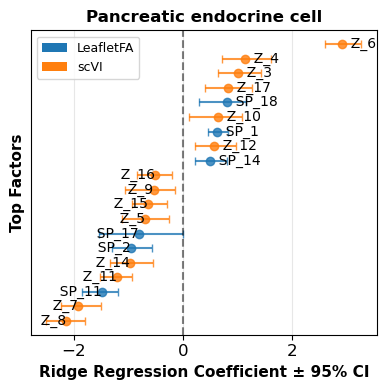

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Nk_cell.pdf


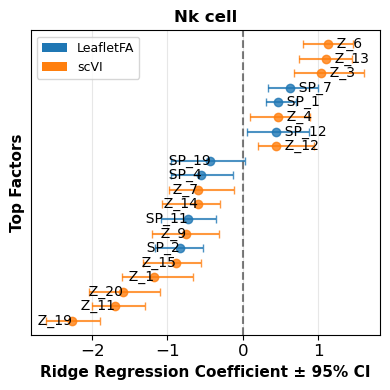

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Microglia.pdf


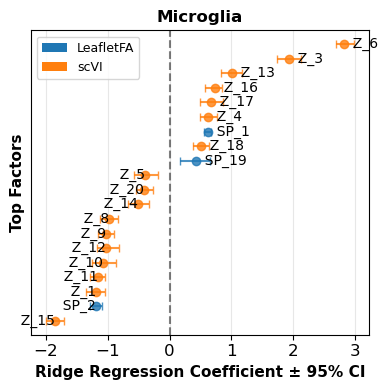

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_T_cell_precursor.pdf


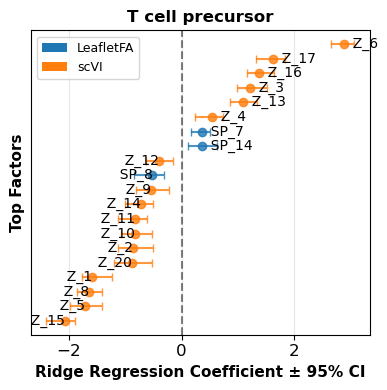

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Kidney_epithelial_cell.pdf


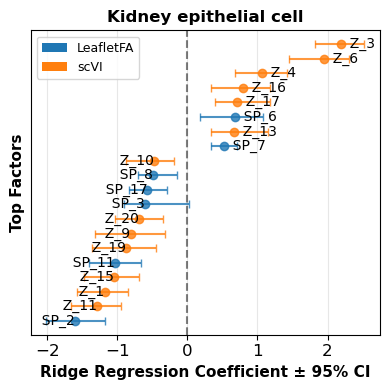

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Skeletal_muscle_cell.pdf


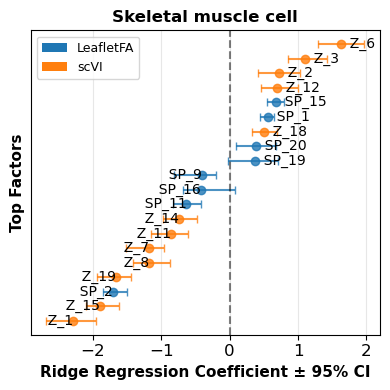

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Hepatocyte.pdf


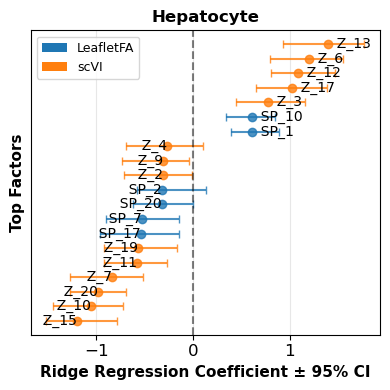

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Pericyte.pdf


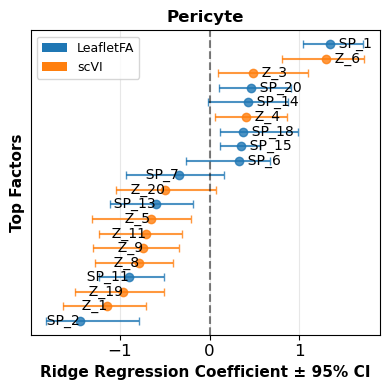

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Macrophage.pdf


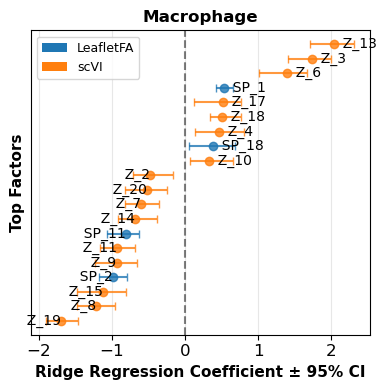

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Hematopoietic_stem_cell.pdf


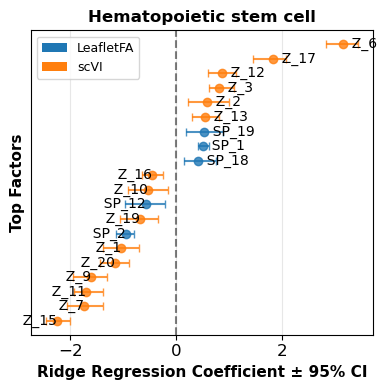

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Astrocyte.pdf


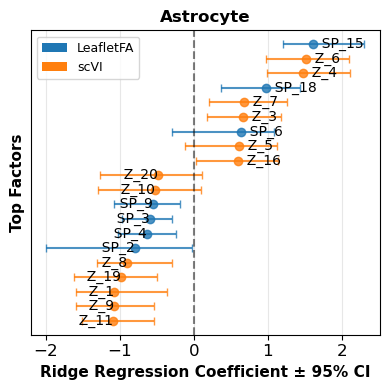

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Specialized_endothelial_cell.pdf


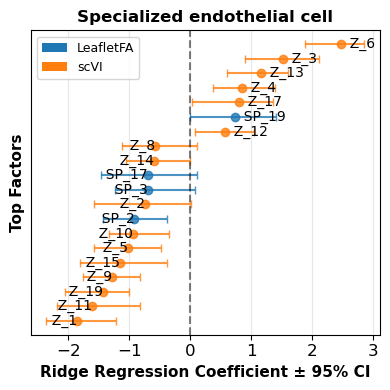

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Specialized_intestinal_cell.pdf


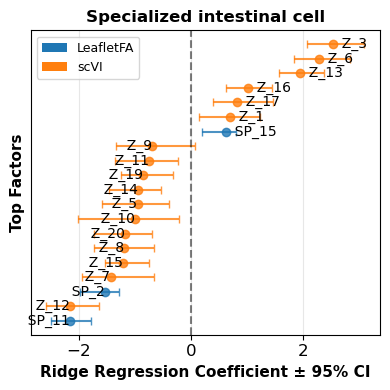

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Oligodendrocyte.pdf


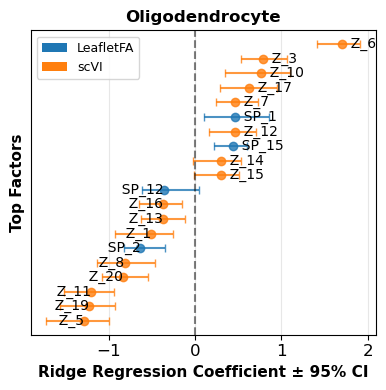

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Monocyte.pdf


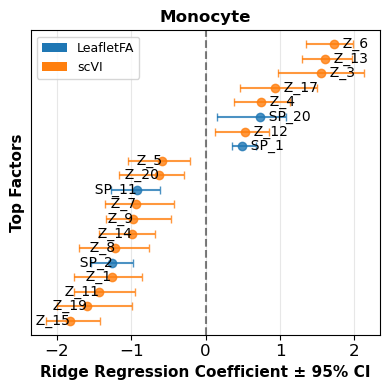

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Mesenchymal_stem_cell.pdf


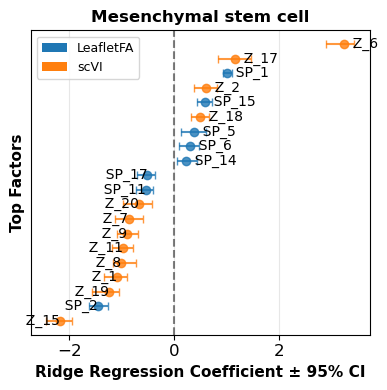

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Stromal_cell.pdf


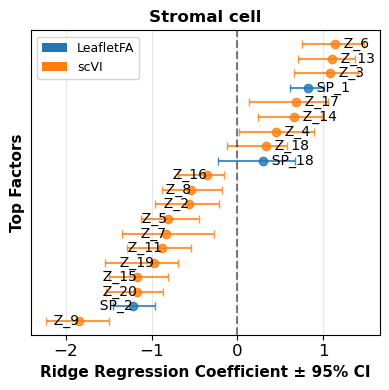

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Other_neuron.pdf


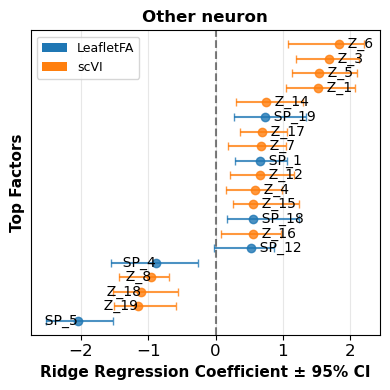

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Pancreatic_exocrine_cell.pdf


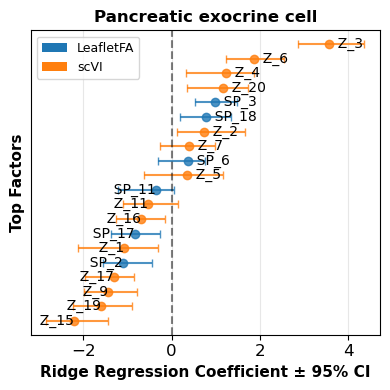

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/forest_plot_Bladder_cell.pdf


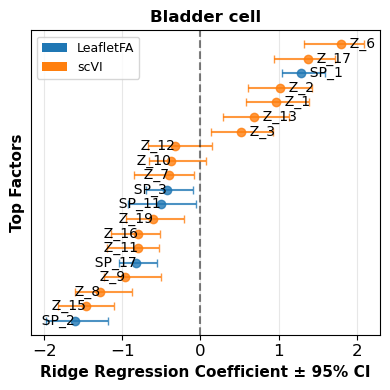

In [33]:
# Make forest plot for every cell type! 
for cell_type in splice_adata.obs["medium_cell_type"].unique():
    create_forest_plot_single_celltype(feature_df_ci, cell_type, paths["output_dir"], top_n_factors=20, figsize=(4, 4))

## Load LeafletFA SP junction markers 
Obtained from `/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/NatureAging_PLOTTING_MOUSE/MOUSE_FIGURE_PLOTS.ipynb`

In [34]:
sj_markers = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/final_df.tsv.gz"
sj_markers_df = pd.read_csv(sj_markers, sep="\t")
sj_markers_df.head()

,old_factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif_y,donor_seq,acceptor_seq,position_off_5_prime_y,position_off_3_prime_y,junction_annotation
0,0,0,0.020312,0.020312,0.000079,0.0,0.00,1.00,False,0.2,...,0.9938,0.9752,213472,217533,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1,0,1,-0.020029,0.020029,0.056855,11.0,0.11,0.89,False,0.2,...,0.0242,1.0000,217533,5258,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
2,0,2,0.344711,0.344711,0.000601,100.0,1.00,0.00,True,0.2,...,0.6404,1.0000,313794,200962,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
3,0,3,-0.199744,0.199744,0.000549,42.0,0.42,0.58,False,0.2,...,0.3570,0.3793,313794,295362,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
4,0,4,0.357117,0.357117,0.000835,100.0,1.00,0.00,True,0.2,...,1.0000,0.6170,182253,295362,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated


Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/sj_markers_aging_effect_size.pdf


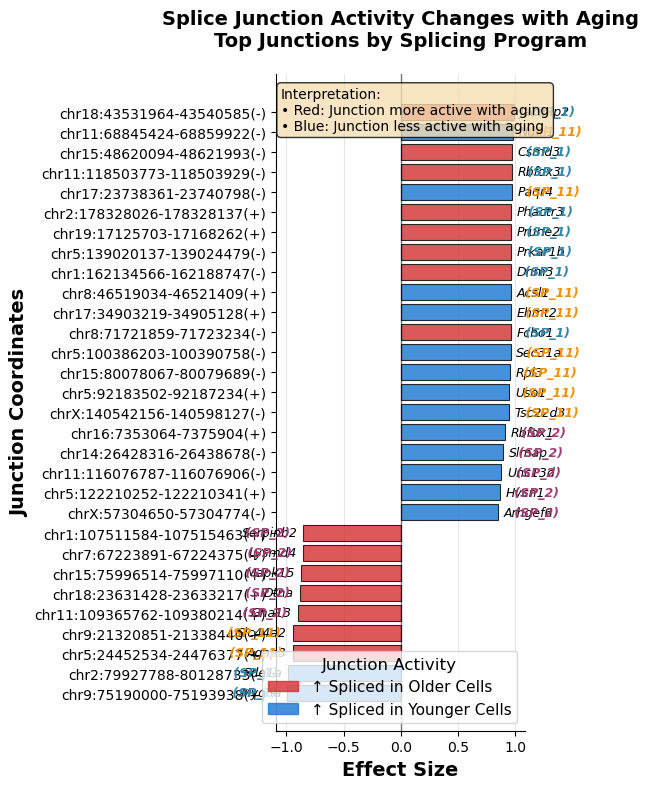

In [35]:
# Set style
plt.style.use('default')

# Define the important factors and their age associations
important_factors = [0, 1, 10]  # SP_1, SP_2, SP_7, SP_11

# Age association direction for each factor (from your feature_df_ci)
age_associations = {
    0: 'positive',   # SP_1: positive coefficient = more active in older cells
    1: 'negative',   # SP_2: negative coefficient = more active in younger cells  
    10: 'negative'   # SP_11: check your feature_df_ci for actual direction
}

# Filter for significant junctions
filtered_df = sj_markers_df[
    (sj_markers_df["factor_idx"].isin(important_factors)) & 
    (sj_markers_df["significant"]) & 
    (sj_markers_df["abs_effect_size"] > 0.25)
].copy()

# Get top N junctions per factor
top_n_per_factor = 10
top_junctions = []
for factor in important_factors:
    factor_data = filtered_df[filtered_df["factor_idx"] == factor]
    if len(factor_data) > 0:
        top_factor_junctions = factor_data.nlargest(top_n_per_factor, 'abs_effect_size')
        top_junctions.append(top_factor_junctions)

plot_data = pd.concat(top_junctions, ignore_index=True)

# Create junction labels
plot_data['junction_label'] = plot_data['junction_id'].str.replace('_', ':', 1).str.replace('_', '-', 1).str.replace('_', '(', 1) + ')'

# Create interpretable effect direction
plot_data['age_direction'] = plot_data.apply(lambda row: 
    'Older' if (age_associations[row['factor_idx']] == 'positive' and row['effect_size'] > 0) or 
              (age_associations[row['factor_idx']] == 'negative' and row['effect_size'] < 0)
    else 'Younger', axis=1)

# Create factor labels with age direction
plot_data['sp_label'] = 'SP_' + (plot_data['factor_idx'] + 1).astype(str)

# Define colors based on age direction instead of just factor
plot_data['color'] = plot_data['age_direction'].map({
    'Older': '#d32f2f',    # Red for increased splicing in older cells
    'Younger': '#1976d2'   # Blue for increased splicing in younger cells
})

# Create the plot
plt.figure(figsize=(6, 8))

# Sort by effect size
plot_data_sorted = plot_data.sort_values('effect_size', ascending=True)

# Create barplot
bars = plt.barh(range(len(plot_data_sorted)), plot_data_sorted['effect_size'], 
                color=plot_data_sorted['color'], 
                alpha=0.8, edgecolor='black', linewidth=0.8)

# Customize labels
plt.yticks(range(len(plot_data_sorted)), 
           plot_data_sorted['junction_label'],
           fontsize=10)

plt.xlabel('Effect Size', fontsize=14, fontweight='bold')
plt.ylabel('Junction Coordinates', fontsize=14, fontweight='bold')
plt.title('Splice Junction Activity Changes with Aging\nTop Junctions by Splicing Program', 
          fontsize=14, fontweight='bold', pad=20)

# Add vertical line at x=0
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5, linewidth=1)

# Add gene names and SP labels with colored SP text
for i, (bar, row) in enumerate(zip(bars, plot_data_sorted.itertuples())):
    width = bar.get_width()
    gene_name = getattr(row, 'gene_name_y', getattr(row, 'gene_name', 'Unknown'))
    sp_label = f"SP_{getattr(row, 'factor_idx')+1}"
    factor_idx = getattr(row, 'factor_idx')
    
    # Define SP colors for text
    sp_text_colors = {0: '#2E86AB', 1: '#A23B72', 10: '#F18F01'}  # Distinct colors for each SP
    
    # Position at the end of the bar
    x_pos = width + (0.05 if width >= 0 else -0.05)
    
    # Create the label with gene name in black and SP in color
    plt.text(x_pos, bar.get_y() + bar.get_height()/2, 
             gene_name, ha='left' if width >= 0 else 'right', 
             va='center', fontsize=9, style='italic', color='black')
    
    # Add SP label in different color, slightly offset
    sp_x_offset = len(gene_name) * 0.008  # Approximate offset based on gene name length
    sp_x_pos = x_pos + (sp_x_offset if width >= 0 else -sp_x_offset)
    
    plt.text(sp_x_pos, bar.get_y() + bar.get_height()/2, 
             f' ({sp_label})', ha='left' if width >= 0 else 'right', 
             va='center', fontsize=9, style='italic', 
             color=sp_text_colors.get(factor_idx, 'black'), fontweight='bold')

# Create age-direction legend
legend_elements = [
    plt.Rectangle((0,0),1,1, color='#d32f2f', alpha=0.8, label='↑ Spliced in Older Cells'),
    plt.Rectangle((0,0),1,1, color='#1976d2', alpha=0.8, label='↑ Spliced in Younger Cells')
]

plt.legend(handles=legend_elements, title='Junction Activity', title_fontsize=12, fontsize=11, 
           loc='lower right')

# Add text box explaining interpretation
textstr = 'Interpretation:\n• Red: Junction more active with aging\n• Blue: Junction less active with aging'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

# Grid and styling
plt.grid(True, alpha=0.3, axis='x')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{paths['output_dir']}/sj_markers_aging_effect_size.pdf", dpi=300, bbox_inches='tight')
# print where plot was saved 
print(f"Plot saved to {paths['output_dir']}/sj_markers_aging_effect_size.pdf")
plt.show()

In [36]:
splicing_aging.layers["denoised_PSI"] = splicing_aging.obsm["X_PHI"] @ splicing_aging.varm["psi_learned"].T

In [37]:
def plot_psi_by_age_violin(splice_adata, junction_idx, OUTPUT_DIR=None, figsize=(4, 4)):
    """
    Create a violin plot showing denoised PSI values by age for a single junction
    """
        
    # Get denoised PSI data and age
    junction_psi = splice_adata.layers["denoised_PSI"][:, junction_idx]  # All cells for this junction
    ages = splice_adata.obs["age_numeric"].values
    junction_id = splice_adata.var["junction_id"].values[junction_idx]

    # Create dataframe for plotting
    plot_df = pd.DataFrame({
        'PSI': junction_psi,
        'Age': ages
    })
    
    # Remove any NaN values
    plot_df = plot_df.dropna()
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Create violin plot with age as continuous variable
    sns.violinplot(data=plot_df, x='Age', y='PSI', 
                  color='#1976d2', alpha=0.7)
    
    # Customize plot
    title = f'Junction {junction_id}'
    plt.title(title, fontsize=11, fontweight='bold')
    plt.xlabel('Age (Months)', fontsize=11, fontweight='bold')
    plt.ylabel('Denoised Junction \nUsage Ratio', fontsize=11, fontweight='bold')

    # Increase tick font size 
    plt.tick_params(axis='both', which='major', labelsize=12)
    
    # Add grid
    plt.grid(True, alpha=0.3)
    plt.gca().set_axisbelow(True)
    
    plt.tight_layout()
    if OUTPUT_DIR:
        plt.savefig(f"{OUTPUT_DIR}/psi_by_age_violin_{junction_id}.pdf", dpi=300, bbox_inches='tight')
        print(f"Plot saved to {OUTPUT_DIR}/psi_by_age_violin_{junction_id}.pdf")
    plt.show()

Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/psi_by_age_violin_chr18_43531964_43540585_-.pdf


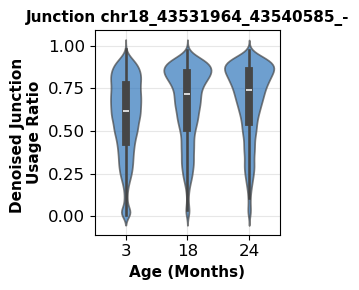

In [38]:
plot_psi_by_age_violin(splicing_aging, junction_idx=13111, OUTPUT_DIR=paths["output_dir"], figsize=(3, 3))

Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/psi_by_age_violin_chr9_75190000_75193938_+.pdf


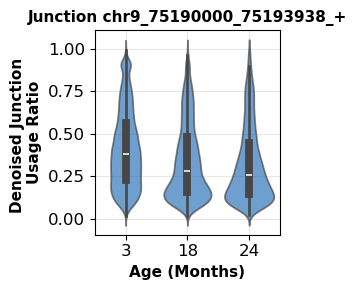

In [39]:
plot_psi_by_age_violin(splicing_aging, junction_idx=33890, OUTPUT_DIR=paths["output_dir"], figsize=(3, 3))

In [40]:
feature_importance_df[feature_importance_df["factor_name"] == "SP_1"].sort_values(by="coefficient", ascending=False)

,cell_type,factor_type,factor_name,coefficient,abs_coefficient,combined_r2,p_vs_scvi
880,Pericyte,Splicing,SP_1,1.345583,1.345583,0.483798,4.933626e-09
1360,Bladder cell,Splicing,SP_1,1.284431,1.284431,0.600993,5.884182e-15
320,Secretory cell,Splicing,SP_1,1.243150,1.243150,0.713702,2.677203e-02
560,Urogenital epithelial cell,Splicing,SP_1,1.235306,1.235306,0.661427,1.110223e-16
1200,Mesenchymal stem cell,Splicing,SP_1,0.996507,0.996507,0.613612,1.110223e-16
80,Endothelial cell,Splicing,SP_1,0.950318,0.950318,0.430737,1.110223e-16
0,Skin epithelial cell,Splicing,SP_1,0.917936,0.917936,0.630622,1.110223e-16
1240,Stromal cell,Splicing,SP_1,0.818469,0.818469,0.747686,1.979530e-10
1280,Other neuron,Splicing,SP_1,0.658373,0.658373,0.390021,1.206507e-09
600,Pancreatic endocrine cell,Splicing,SP_1,0.634683,0.634683,0.622351,1.110223e-16


## RBP analysis FIgure 4 !

In [41]:
SP1_cells = feature_importance_df[feature_importance_df["factor_name"] == "SP_1"].sort_values(by="coefficient", ascending=False)
SP2_cells = feature_importance_df[feature_importance_df["factor_name"] == "SP_2"].sort_values(by="coefficient", ascending=True)

In [42]:
# Keep only where combined_r2 > 0.5 and p_vs_scvi < 0.05
SP1_cells = SP1_cells[(SP1_cells["p_vs_scvi"] < 0.05) & (SP1_cells["coefficient"] > 0.5)]
SP2_cells = SP2_cells[(SP2_cells["p_vs_scvi"] < 0.05) & (SP2_cells["coefficient"] < 0.5)]

In [43]:
assert all(ge_adata_aging.obs_names == splicing_aging.obs_names)

In [44]:
ge_adata_aging.layers["scVI_linear"] = ge_adata_aging.obsm["X_normalized_scVI_linear"]

### Running RBP expression vs SP1, SP2 and age correlation

In [45]:
# 2. Get overlapping cell types between SP1 and SP2
sp1_cell_types = set(SP1_cells['cell_type'].values)
sp2_cell_types = set(SP2_cells['cell_type'].values)
overlapping_cell_types = list(sp1_cell_types & sp2_cell_types)
print(f"\nOverlapping cell types: length {len(overlapping_cell_types)}")
print(overlapping_cell_types)

# 1. Extract RBP genes and their expression
print("Extracting RBP genes...")
rbp_genes = ge_adata_aging.var[ge_adata_aging.var['is_rbp']].index.tolist()
print(f"Found {len(rbp_genes)} RBP genes")

# 3. Ensure SP scores are in ge_adata
if 'SP_1' not in ge_adata_aging.obs.columns:  
    # Match cells between splice_adata and ge_adata
    ge_adata_aging.obs.loc[:, 'SP_1'] = splicing_aging.obs.loc[:, 'SP_1']   
    ge_adata_aging.obs.loc[:, 'SP_2'] = splicing_aging.obs.loc[:, 'SP_2']


Overlapping cell types: length 19
['Endothelial cell', 'Intestinal epithelial cell', 'Skin epithelial cell', 'Stromal cell', 'Urogenital epithelial cell', 'Cardiac stromal cell', 'Microglia', 'Mesenchymal stem cell', 'Hematopoietic stem cell', 'Pericyte', 'Bladder cell', 'Immune progenitor', 'Fibroblast', 'Macrophage', 'Pancreatic endocrine cell', 'Hepatocyte', 'Skeletal muscle cell', 'Secretory cell', 'Other neuron']
Extracting RBP genes...
Found 287 RBP genes


In [46]:
# save overlapping_cell_types to file, tilted figure 4 cecll types sp1_sp2_overlapping_cell_types.txt
# save in paths["output_dir"]
with open(os.path.join(paths["output_dir"], "tilted_figure_4_cell_types_sp1_sp2_overlapping_cell_types.txt"), "w") as f:
    for cell_type in overlapping_cell_types:
        f.write(f"{cell_type}\n")

print(f"Saved in {paths['output_dir']}/tilted_figure_4_cell_types_sp1_sp2_overlapping_cell_types.txt")

Saved in /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/tilted_figure_4_cell_types_sp1_sp2_overlapping_cell_types.txt


In [47]:
from statsmodels.stats.multitest import multipletests
import pingouin as pg

def simple_mediation_analysis(ge_adata_aging, splicing_aging, rbp_genes, cell_type, n_boot=1000):
    """Simple mediation analysis for one cell type."""
    
    # Align splicing data
    for col in ["SP_1", "SP_2"]:
        if col not in ge_adata_aging.obs.columns:
            ge_adata_aging.obs[col] = splicing_aging.obs[col].reindex(ge_adata_aging.obs_names).values
    
    # Subset to cell type
    mask = ge_adata_aging.obs["medium_cell_type"] == cell_type
    ct = ge_adata_aging[mask].copy()
    print(f"{cell_type}: {ct.n_obs} cells")
    
    # Skip cell type if too few cells
    if ct.n_obs <= 500:
        print(f"Skipping {cell_type}: only {ct.n_obs} cells")
        return pd.DataFrame()
        
    # Get available RBPs
    available_rbps = [rbp for rbp in rbp_genes if rbp in ct.var_names]
    print(f"Testing {len(available_rbps)} RBPs")
    
    # Run mediation for all RBPs
    results = []
    for rbp in tqdm(available_rbps):
        # Get RBP expression
        rbp_expr = np.asarray(ct[:, rbp].layers["scVI_linear"]).ravel()
        
        # Skip if no variation
        if np.std(rbp_expr) == 0:
            continue
            
        # Skip if RBP is expressed in fewer than 5% of cells
        if np.mean(rbp_expr > 0) < 0.05:
            continue

        # Build dataframe
        df = pd.DataFrame({
            "Age": ct.obs["age_numeric"].values,
            "RBP_expr": rbp_expr,
            "SP1": ct.obs["SP_1"].values,
            "SP2": ct.obs["SP_2"].values,
            "SPdiff": ct.obs["SP_1"].values - ct.obs["SP_2"].values
        })
        
        # Test each outcome
        for outcome in ["SP1", "SP2", "SPdiff"]:
            d = df[["Age", "RBP_expr", outcome]].dropna().rename(columns={outcome: "Y"})
            
            if len(d) < 50 or d["Y"].std() == 0:
                continue
                
            try:
                res = pg.mediation_analysis(data=d, x="Age", m="RBP_expr", y="Y", n_boot=n_boot, seed=42)
                res["RBP"] = rbp
                res["Outcome"] = outcome
                res["CellType"] = cell_type
                results.append(res)
            except:
                continue
    
    # Combine results
    if not results:
        return pd.DataFrame()
        
    all_results = pd.concat(results, ignore_index=True)
    print(all_results.head)
    
    # FDR correction for indirect effects only
    indirect = all_results[all_results['path'] == 'Indirect'].copy()
    _, pvals_corrected, _, _ = multipletests(indirect['pval'], method='fdr_bh')
    indirect['pval_fdr'] = pvals_corrected
    
    # Get significant mediations
    indirect['effect_size'] = np.abs(indirect['coef'])
    indirect = indirect.sort_values('effect_size', ascending=False)
    
    return indirect

# Usage:
all_res = []
for cell_type in tqdm(overlapping_cell_types): # cell types with strong SP1/SP2 coefficients 
    results = simple_mediation_analysis(ge_adata_aging, splicing_aging, rbp_genes, cell_type, n_boot=10)
    all_res.append(results)

  0%|          | 0/19 [00:00<?, ?it/s]

Endothelial cell: 7065 cells
Testing 287 RBPs


  5%|▌         | 1/19 [01:21<24:19, 81.09s/it]

<bound method NDFrame.head of               path          coef            se           pval      CI[2.5%]  \
0     RBP_expr ~ X -1.231183e-07  3.925454e-08   1.717335e-03 -2.000690e-07   
1     Y ~ RBP_expr -4.708728e+02  7.502597e+01   3.676327e-10 -6.179462e+02   
2            Total  4.441764e-03  2.426856e-04   3.800123e-73  3.966028e-03   
3           Direct  4.389897e-03  2.423072e-04   9.666132e-72  3.914902e-03   
4         Indirect  5.186748e-05  2.324351e-05   0.000000e+00  2.718911e-05   
...            ...           ...           ...            ...           ...   
4300  RBP_expr ~ X -2.511161e-06  1.414140e-07   4.701904e-69 -2.788375e-06   
4301  Y ~ RBP_expr -1.729801e+02  2.177704e+01   2.276002e-15 -2.156696e+02   
4302         Total  6.408542e-03  2.545290e-04  4.933255e-134  5.909589e-03   
4303        Direct  6.240879e-03  2.599881e-04  1.808529e-122  5.731224e-03   
4304      Indirect  1.676631e-04  5.329464e-05   0.000000e+00  1.123093e-04   

         CI[97.5%]  s

 11%|█         | 2/19 [01:49<14:07, 49.86s/it]

...

<bound method NDFrame.head of               path          coef            se          pval      CI[2.5%]  \
0     RBP_expr ~ X -2.372832e-07  1.125694e-07  3.538998e-02 -4.582909e-07   
1     Y ~ RBP_expr  9.115809e+02  3.149297e+02  3.913145e-03  2.932790e+02   
2            Total  7.690681e-03  9.099199e-04  1.611199e-16  5.904234e-03   
3           Direct  7.956326e-03  9.045933e-04  1.067851e-17  6.180333e-03   
4         Indirect -2.656457e-04  1.860705e-04  0.000000e+00 -5.189548e-04   
...            ...           ...           ...           ...           ...   
4300  RBP_expr ~ X -5.304755e-07  2.286831e-07  2.063921e-02 -9.794492e-07   
4301  Y ~ RBP_expr  5.667220e+02  1.758032e+02  1.323575e-03  2.215672e+02   
4302         Total  7.883791e-03  1.043614e-03  1.295805e-13  5.834862e-03   
4303        Direct  8.246277e-03  1.036468e-03  7.005128e-15  6.211372e-03   
4304      Indirect -3.624865e-04  2.267711e-04  0.000000e+00 -7.139730e-04   

         CI[97.5%]  sig     RBP O

 89%|████████▉ | 17/19 [10:39<00:57, 28.87s/it]

<bound method NDFrame.head of               path        coef            se           pval    CI[2.5%]  \
0     RBP_expr ~ X   -0.000003  1.110518e-07  2.593681e-136   -0.000003   
1     Y ~ RBP_expr  138.738238  5.519316e+01   1.201091e-02   30.508539   
2            Total    0.001326  3.444413e-04   1.211077e-04    0.000651   
3           Direct    0.002228  3.885422e-04   1.104659e-08    0.001466   
4         Indirect   -0.000902  1.925351e-04   0.000000e+00   -0.001124   
...            ...         ...           ...            ...         ...   
4300  RBP_expr ~ X   -0.000008  2.253344e-07  2.474060e-245   -0.000009   
4301  Y ~ RBP_expr -354.687739  2.908684e+01   2.967141e-33 -411.724883   
4302         Total    0.007017  3.961226e-04   3.421029e-66    0.006240   
4303        Direct    0.006311  4.965270e-04   6.741596e-36    0.005337   
4304      Indirect    0.000706  3.891134e-04   0.000000e+00    0.000419   

       CI[97.5%]  sig     RBP Outcome              CellType  
0      

100%|██████████| 19/19 [10:59<00:00, 34.70s/it]

<bound method NDFrame.head of               path          coef            se          pval      CI[2.5%]  \
0     RBP_expr ~ X  1.230857e-07  1.204963e-07  3.074356e-01 -1.135617e-07   
1     Y ~ RBP_expr -2.073598e+03  2.750587e+02  1.768219e-13 -2.613796e+03   
2            Total  1.519922e-03  8.465948e-04  7.310496e-02 -1.427382e-04   
3           Direct  1.778250e-03  8.093220e-04  2.838894e-02  1.887856e-04   
4         Indirect -2.583278e-04  1.442871e-04  0.000000e+00 -4.257354e-04   
...            ...           ...           ...           ...           ...   
4300  RBP_expr ~ X -1.454496e-07  5.812806e-07  8.025011e-01 -1.287049e-06   
4301  Y ~ RBP_expr -3.763905e+02  5.656162e+01  6.432769e-11 -4.874740e+02   
4302         Total  1.473343e-03  8.311038e-04  7.677847e-02 -1.588944e-04   
4303        Direct  1.418745e-03  8.026638e-04  7.764759e-02 -1.576427e-04   
4304      Indirect  5.459731e-05  1.015273e-04  6.000000e-01 -3.605562e-05   

         CI[97.5%]  sig     RBP O

In [48]:
all_res_df = pd.concat(all_res, ignore_index=True)

# Significant SPdiff hits
sig_hits = (
    all_res_df
    .query("path == 'Indirect' and pval_fdr < 0.05 and Outcome == 'SPdiff'")
    .copy()
)

# Top 5 per cell type
top_per_cell = (
    sig_hits
    .sort_values(["CellType", "effect_size"], ascending=[True, False])
    .groupby("CellType")
    .head(5)
)

# Keep only these RBPs & cell types in the full results
rbps_keep = top_per_cell["RBP"].unique()
cell_types_keep = top_per_cell["CellType"].unique()

subset_df = all_res_df[
    all_res_df["RBP"].isin(rbps_keep) &
    all_res_df["CellType"].isin(cell_types_keep) &
    (all_res_df["Outcome"] == "SPdiff") &
    (all_res_df["path"] == "Indirect")
].copy()

# Pivot to RBP × CellType matrix (effect size or coef)
heatmap_df = subset_df.pivot(index="RBP", columns="CellType", values="coef").fillna(0)
value_col = "coef" if "coef" in subset_df.columns else "effect_size"

In [49]:
print(f"The number of RBPs is {heatmap_df.shape[0]} and the number of cell types is {heatmap_df.shape[1]}")

The number of RBPs is 52 and the number of cell types is 17


In [50]:
# Choose value column
value_col = "coef" if "coef" in subset_df.columns else "effect_size"

# Collapse to one row per (RBP, CellType): take the row with the smallest FDR
pair_df = (
    subset_df.sort_values("pval_fdr")
             .drop_duplicates(["RBP", "CellType"])
)

# Values for heatmap
heatmap_df = (
    pair_df.pivot(index="RBP", columns="CellType", values=value_col)
           .fillna(0)
)

# Significance mask (FDR<0.05)
sig_mask = (
    (pair_df.assign(sig=lambda d: d["pval_fdr"] < 0.05))
    .pivot(index="RBP", columns="CellType", values="sig")
    .fillna(False)
)

# Ensure same index/columns in both
sig_mask = sig_mask.reindex(index=heatmap_df.index, columns=heatmap_df.columns, fill_value=False)

In [51]:
rbp_summary = {}
for rbp in heatmap_df.index:
    sig_vals = []
    for ct in heatmap_df.columns:
        if sig_mask.loc[rbp, ct]:
            sig_vals.append(heatmap_df.loc[rbp, ct])

    if not sig_vals:  # no significant hits
        rbp_summary[rbp] = "No significant associations"
        continue

    pos_frac = sum(v > 0 for v in sig_vals) / len(sig_vals)
    neg_frac = sum(v < 0 for v in sig_vals) / len(sig_vals)

    if pos_frac >= 0.75:
        rbp_summary[rbp] = "Broad aging-promoter (positive in most cell types)"
    elif neg_frac >= 0.75:
        rbp_summary[rbp] = "Broad youth-associated / aging-protective (negative in most cell types)"
    else:
        rbp_summary[rbp] = "Mixed / cell-type-specific effect"

rbp_summary_df = pd.DataFrame.from_dict(rbp_summary, orient="index", columns=["Interpretation"])
rbp_summary_df["Interpretation"].value_counts()

Interpretation
Mixed / cell-type-specific effect                                          26
Broad youth-associated / aging-protective (negative in most cell types)    13
Broad aging-promoter (positive in most cell types)                         13
Name: count, dtype: int64

RBP_SPdiff_mediation.pdf saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/RBP_SPdiff_mediation.pdf


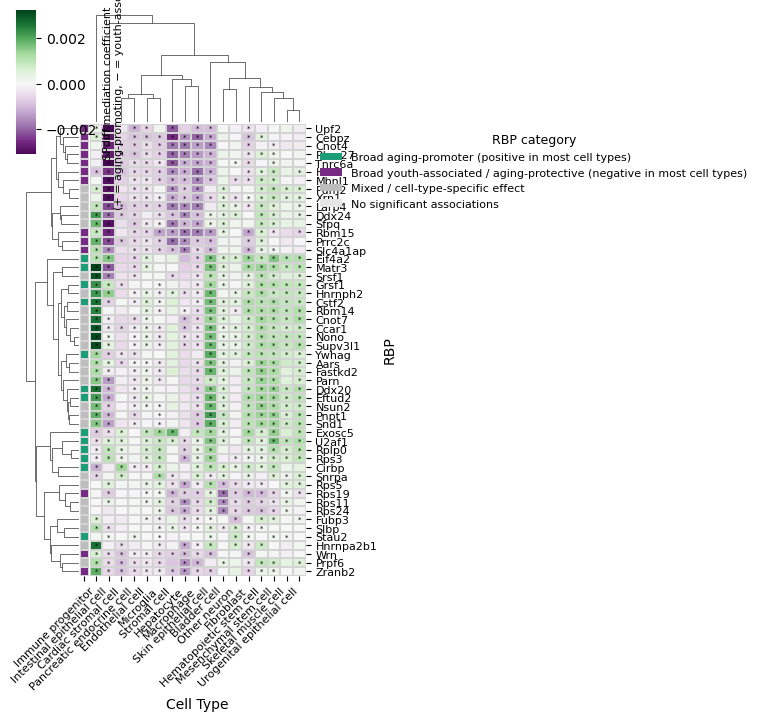

In [52]:
# --- 0) Reformat gene names to mouse style ---
heatmap_df.index = [name.capitalize() for name in heatmap_df.index]
sig_mask.index   = [name.capitalize() for name in sig_mask.index]
rbp_summary_df.index = [s.capitalize() for s in rbp_summary_df.index]

# --- 1) Choose category → color mapping ---
# (A) Match heatmap PRGn semantics (green = aging-promoter, purple = youth)
cat2color = {
    "Broad aging-promoter (positive in most cell types)"          : "#1b9e77",  # green
    "Broad youth-associated / aging-protective (negative in most cell types)" : "#762a83",  # purple
    "Mixed / cell-type-specific effect"                           : "#bdbdbd",
    "No significant associations"                                 : "#e6e6e6",
}

# # (B) Blue/Red alternative
# cat2color = {
#     "Broad aging-promoter (positive in most cell types)"          : "#d73027",  # red
#     "Broad youth-associated / aging-protective (negative in most cell types)" : "#4575b4",  # blue
#     "Mixed / cell-type-specific effect"                           : "#bdbdbd",
#     "No significant associations"                                 : "#e6e6e6",
# }

# --- 2) Build row_colors aligned to heatmap_df.index ---
row_categories = (
    pd.Series(index=heatmap_df.index, dtype=object)
      .apply(lambda _: "No significant associations")
)
row_categories.update(rbp_summary_df["Interpretation"])  # fill where we have a label
row_colors = row_categories.map(cat2color)

# --- 3) Plot with row_colors ---
figsize = (4, 8)
g = sns.clustermap(
    data=heatmap_df,
    cmap="PRGn",
    center=0,
    row_cluster=True,
    col_cluster=True,
    linewidths=0.15,
    linecolor="lightgray",
    xticklabels=True,
    yticklabels=True,
    figsize=figsize,
    row_colors=row_colors,
)

# Axis labels
g.ax_heatmap.set_xlabel("Cell Type", fontsize=10)
g.ax_heatmap.set_ylabel("RBP", fontsize=10)

# Colorbar label
g.ax_cbar.set_ylabel("SPdiff mediation coefficient\n(+ = aging-promoting, − = youth-associated)", fontsize=8)

# Rotate/align x labels cleanly
for lbl in g.ax_heatmap.get_xticklabels():
    lbl.set_rotation(45)
    lbl.set_horizontalalignment('right')
    lbl.set_fontsize(8)
g.ax_heatmap.tick_params(axis='y', labelsize=8)

# Stars for FDR<0.05
row_order = [heatmap_df.index[i]   for i in g.dendrogram_row.reordered_ind]
col_order = [heatmap_df.columns[i] for i in g.dendrogram_col.reordered_ind]
for i, rbp in enumerate(row_order):
    for j, ct in enumerate(col_order):
        if sig_mask.loc[rbp, ct]:
            g.ax_heatmap.text(j + 0.5, i + 0.5, "*",
                              ha="center", va="center",
                              fontsize=5, color="black", clip_on=True)

# Legend for the row color strip
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, edgecolor='none', label=k) for k, c in cat2color.items()]
g.ax_heatmap.legend(
    handles=handles,
    title="RBP category",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
    fontsize=8,
    title_fontsize=9
)

# --- 4) Save figure ---
plt.savefig(f"{paths['output_dir']}/RBP_SPdiff_mediation.pdf", bbox_inches='tight')
print(f"RBP_SPdiff_mediation.pdf saved to {paths['output_dir']}/RBP_SPdiff_mediation.pdf")

plt.show()

In [53]:
heatmap_df.index

Index(['Aars', 'Ccar1', 'Cebpz', 'Cirbp', 'Cnot4', 'Cnot7', 'Cstf2', 'Ddx20',
       'Ddx24', 'Eftud2', 'Eif4a2', 'Exosc5', 'Fastkd2', 'Fubp3', 'Grsf1',
       'Hltf', 'Hnrnpa2b1', 'Hnrnph2', 'Larp4', 'Matr3', 'Mbnl1', 'Nono',
       'Nsun2', 'Parn', 'Pnpt1', 'Prpf6', 'Prrc2c', 'Pum2', 'Rbm14', 'Rbm15',
       'Rbm27', 'Rplp0', 'Rps11', 'Rps19', 'Rps24', 'Rps3', 'Rps5', 'Sfpq',
       'Slbp', 'Slc4a1ap', 'Snd1', 'Snrpa', 'Srsf1', 'Stau2', 'Supv3l1',
       'Tnrc6a', 'U2af1', 'Upf2', 'Wrn', 'Xrn1', 'Ywhag', 'Zranb2'],
      dtype='object')

In [54]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def plot_mediation_landscape_simple(
    mediation_results,
    ge_adata_aging,
    cell_type,
    save_dir,
    effect_threshold=1e-4,
    top_labels=8,
    point_size=28,
    add_quadrant_labels=True,
):
    """
    Scatter for one cell type:
      x-axis: SPdiff mediation coefficient (Indirect path)
              (>0: aging-promoting; <0: youth-protective)
      y-axis: Spearman corr(RBP expression, age)
              (>0: RBP up with age; <0: RBP down with age)
    Color: SPdiff mediation coefficient (diverging, centered at 0)
    Saves PDF to <save_dir>/<cell_type>_RBP_landscape.pdf
    """
    # --- filter to SPdiff, indirect path, this cell type ---
    ct = mediation_results.query(
        "CellType == @cell_type and path == 'Indirect' and Outcome == 'SPdiff'"
    ).copy()
    if ct.empty:
        print(f"No SPdiff indirect rows for {cell_type}.")
        return pd.DataFrame()

    # one row per (RBP, CellType): keep smallest FDR (or pval)
    if "pval_fdr" in ct.columns:
        ct = (ct.sort_values("pval_fdr")
                .drop_duplicates(["RBP", "CellType"], keep="first"))
    else:
        ct = (ct.sort_values("pval")
                .drop_duplicates(["RBP", "CellType"], keep="first"))

    # --- compute RBP–age Spearman correlations in this cell type ---
    mask = ge_adata_aging.obs["medium_cell_type"] == cell_type
    if mask.sum() < 50:
        print(f"Too few cells for {cell_type}: {mask.sum()}")
        return pd.DataFrame()

    ages = ge_adata_aging.obs.loc[mask, "age_numeric"].astype(float).values
    rbps = [rbp for rbp in ct["RBP"].unique() if rbp in ge_adata_aging.var_names]
    if not rbps:
        print(f"No RBPs from mediation present in ge_adata_aging for {cell_type}.")
        return pd.DataFrame()

    age_corr = {}
    for rbp in rbps:
        try:
            expr = np.asarray(ge_adata_aging[mask, rbp].layers["scVI_linear"]).ravel()
        except Exception:
            expr = np.asarray(ge_adata_aging[mask, rbp].X).ravel()
        if np.std(expr) == 0 or np.isnan(expr).any():
            continue
        rho, _ = spearmanr(expr, ages)
        age_corr[rbp] = rho
    if not age_corr:
        print(f"No valid age correlations computed for {cell_type}.")
        return pd.DataFrame()

    # --- assemble plotting frame ---
    P = (
        ct.set_index("RBP")[["coef"]]
          .rename(columns={"coef": "med_coef"})
          .join(pd.Series(age_corr, name="age_corr"), how="inner")
          .dropna()
    )
    P = P.loc[P["med_coef"].abs() > effect_threshold]
    if P.empty:
        print(f"No RBPs pass |SPdiff coef| > {effect_threshold} in {cell_type}.")
        return P

    # --- plot ---
    fig, ax = plt.subplots(figsize=(4, 3))

    vmax = float(np.nanmax(np.abs(P["med_coef"])))
    sc = ax.scatter(
        P["med_coef"], P["age_corr"],
        c=P["med_coef"], cmap="PRGn", vmin=-vmax, vmax=vmax,
        s=point_size, edgecolors="black", linewidths=0.1, alpha=0.9
    )

    # axes crosshairs
    ax.axhline(0, color="black", ls="--", lw=0.6, alpha=0.5)
    ax.axvline(0, color="black", ls="--", lw=0.6, alpha=0.5)

    ax.set_xlabel("SPdiff mediation coefficient", fontsize=10)
    ax.set_ylabel("Spearman corr(RBP expression, age)", fontsize=10)
    ax.set_title(f"RBP:landscape:{cell_type}", fontsize=5, pad=6)

    for lbl in ax.get_xticklabels():
        lbl.set_rotation(45)
    ax.tick_params(axis="both", labelsize=11)

    # colorbar
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Mediation coef", fontsize=6)
    cbar.ax.tick_params(labelsize=7)

    # label top points by |coef|
    for rbp in P["med_coef"].abs().nlargest(min(top_labels, len(P))).index:
        ax.annotate(
            rbp, (P.at[rbp, "med_coef"], P.at[rbp, "age_corr"]),
            xytext=(5, 3), textcoords="offset points",
            fontsize=6, 
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
        )

    # --- quadrant annotations (axes-relative, no unpack bug) ---
    if add_quadrant_labels:
        pos = {
            "Q1": (0.78, 0.88),  # x>0,y>0
            "Q2": (0.12, 0.88),  # x<0,y>0
            "Q3": (0.12, 0.12),  # x<0,y<0
            "Q4": (0.78, 0.12),  # x>0,y<0
        }
        qtext = {
            "Q1": "Aging-promoter\n↑ with age",
            "Q2": "Youth-protective\n↑ with age",
            "Q3": "Youth-protective\n↓ with age",
            "Q4": "Aging-promoter\n↓ with age",
        }
        for q, label in qtext.items():
            x, y = pos[q]
            ax.text(
                x, y, label,
                transform=ax.transAxes,
                ha="center", va="center",
                fontsize=7,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none"),
            )

    plt.tight_layout()

    # --- save as PDF ---
    os.makedirs(save_dir, exist_ok=True)
    pdf_path = os.path.join(save_dir, f"{cell_type}_RBP_landscape.pdf")
    # replace any spaces with underscores
    pdf_path = pdf_path.replace(" ", "_")
    plt.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    plt.show()
    return P

In [55]:
all_res_df["RBP"] = all_res_df["RBP"].str.capitalize()

In [56]:
ge_adata_aging.var["mouse_gene_name"] = ge_adata_aging.var["index"]
ge_adata_aging.var_names = ge_adata_aging.var["mouse_gene_name"]
ge_adata_aging

AnnData object with n_obs × n_vars = 84047 × 2482
    obs: 'cell_id', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'tissue', 'dataset', 'batch', 'subtissue_clean', 'broad_cell_type', 'cell_id_index', 'specific_cell_type', 'medium_cell_type', 'cell_name', 'library_size', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_is_rRNA', 'log1p_total_counts_is_rRNA', 'pct_counts_is_rRNA', 'nuclear_score_log_norm', 'nuclear_ratio_log_norm', 'nuclear_rrna_log_norm', 'nuclear_class_log_norm', 'nuclear_score_predicted_log_norm_tms', 'nuclear_ratio_predicted_log_norm_tms', 'nuclear_rrna_predicted_log_norm_tms', 'nuclear_class_predicted_log_norm_tms', 'AgingScore_pos', 'AgingScore_neg', 'AgingScore_unweighted', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'age_numeric', 'SP_1', 'SP_2'
    var: 'index', 'gene_name', 'gene_id', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'transcript_biotypes', 'is_rRNA', 'n_cells_by_counts', 

### Mediation already calcualted for Sp1-Ps2 ~ RBP ~ Age so here can just simply plot SP1-SP2 activity versus RBP expression... 

In [57]:
all_res_df

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig,RBP,Outcome,CellType,pval_fdr,effect_size
0,Indirect,9.012978e-04,0.000054,0.0,0.000846,0.000921,Yes,Exosc5,SPdiff,Endothelial cell,0.000000,9.012978e-04
1,Indirect,-8.767123e-04,0.000126,0.0,-0.001116,-0.000716,Yes,Cebpz,SPdiff,Endothelial cell,0.000000,8.767123e-04
2,Indirect,7.059444e-04,0.000077,0.0,0.000608,0.000832,Yes,Cstf2,SP1,Endothelial cell,0.000000,7.059444e-04
3,Indirect,6.897613e-04,0.000051,0.0,0.000595,0.000740,Yes,Rplp0,SPdiff,Endothelial cell,0.000000,6.897613e-04
4,Indirect,6.608859e-04,0.000107,0.0,0.000576,0.000901,Yes,Rc3h1,SP1,Endothelial cell,0.000000,6.608859e-04
...,...,...,...,...,...,...,...,...,...,...,...,...
14632,Indirect,4.842228e-07,0.000017,0.8,-0.000022,0.000024,No,Ilf3,SP2,Other neuron,0.846192,4.842228e-07
14633,Indirect,4.501080e-07,0.000047,0.8,-0.000086,0.000050,No,Eif4h,SP2,Other neuron,0.846192,4.501080e-07
14634,Indirect,3.531245e-07,0.000075,1.0,-0.000120,0.000104,No,Fubp1,SP2,Other neuron,1.000000,3.531245e-07
14635,Indirect,6.916468e-08,0.000025,0.8,-0.000027,0.000032,No,Pa2g4,SP2,Other neuron,0.846192,6.916468e-08


Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Bladder_cell_RBP_landscape.pdf


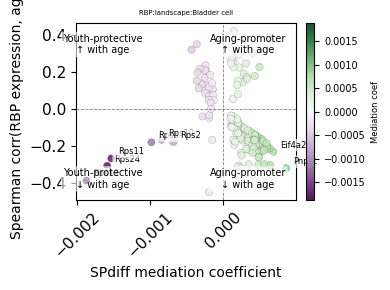

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Cardiac_stromal_cell_RBP_landscape.pdf


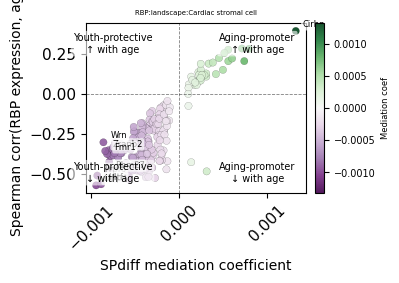

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Endothelial_cell_RBP_landscape.pdf


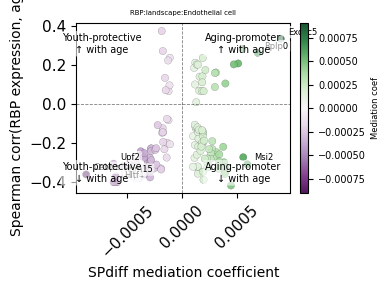

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Fibroblast_RBP_landscape.pdf


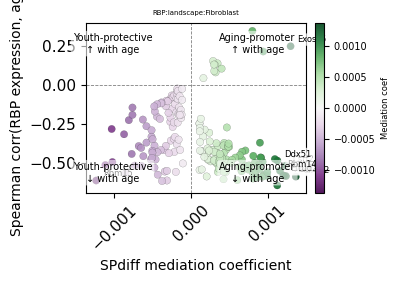

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Hematopoietic_stem_cell_RBP_landscape.pdf


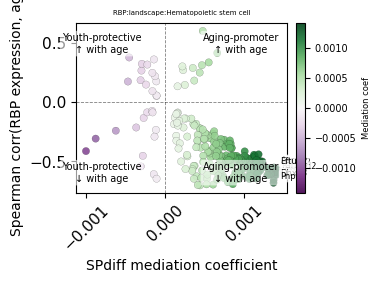

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Hepatocyte_RBP_landscape.pdf


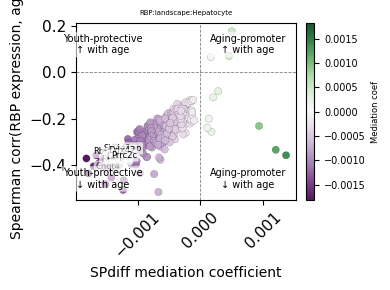

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Immune_progenitor_RBP_landscape.pdf


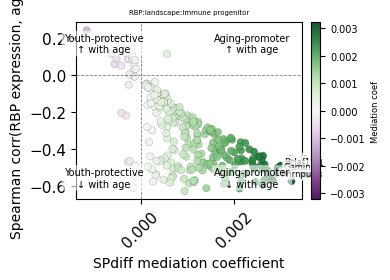

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Intestinal_epithelial_cell_RBP_landscape.pdf


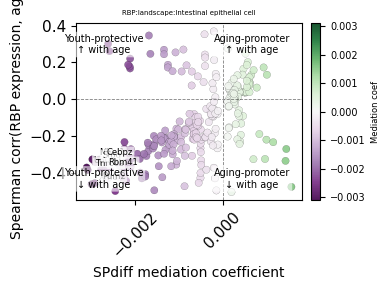

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Macrophage_RBP_landscape.pdf


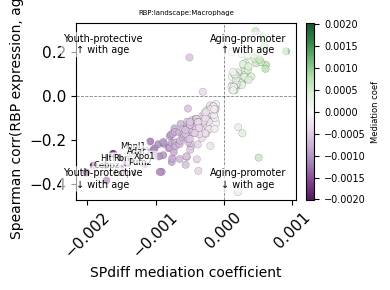

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Mesenchymal_stem_cell_RBP_landscape.pdf


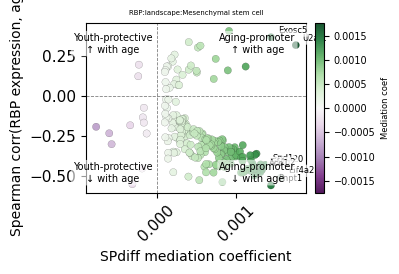

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Microglia_RBP_landscape.pdf


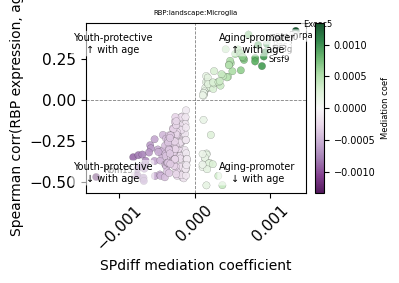

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Other_neuron_RBP_landscape.pdf


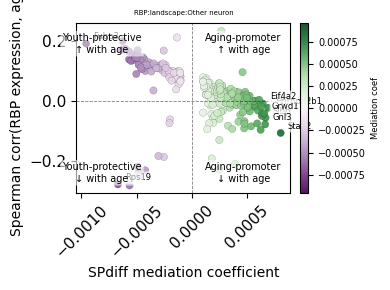

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Pancreatic_endocrine_cell_RBP_landscape.pdf


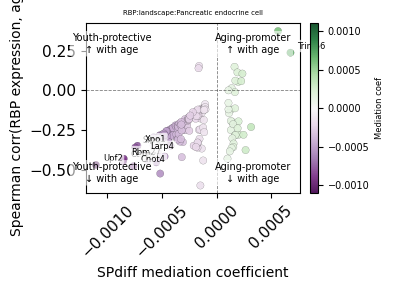

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Skeletal_muscle_cell_RBP_landscape.pdf


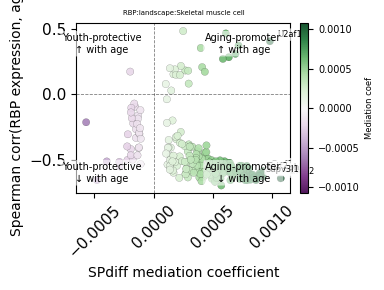

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Skin_epithelial_cell_RBP_landscape.pdf


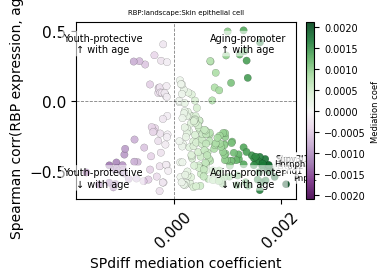

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Stromal_cell_RBP_landscape.pdf


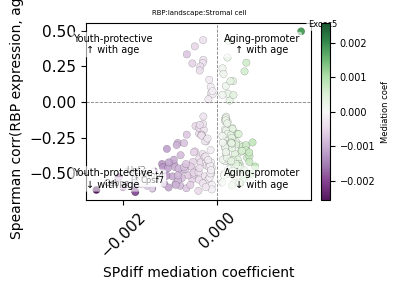

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/Urogenital_epithelial_cell_RBP_landscape.pdf


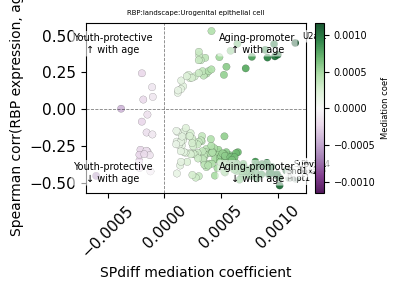

In [58]:
for ct in sorted(all_res_df["CellType"].dropna().unique()):
    plot_mediation_landscape_simple(
        mediation_results=all_res_df,
        ge_adata_aging=ge_adata_aging,
        cell_type=ct,
        save_dir=paths["output_dir"],
    )

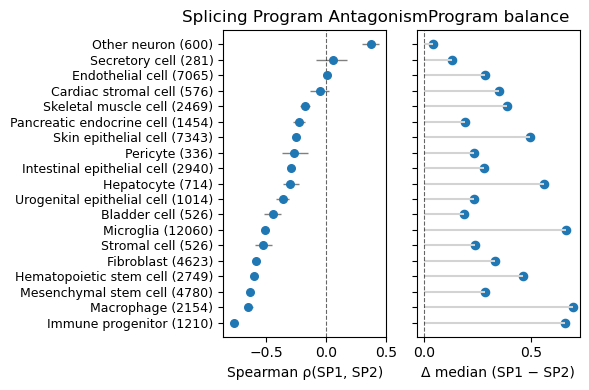

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/panelB_antagonism_and_balance_bootstrap.pdf


In [59]:
# import package for rankdata 
from scipy.stats import rankdata, spearmanr

# --- CI helpers ---
def spearman_ci_fast(x, y, alpha=0.05):
    """Spearman via Pearson-on-ranks + Fisher z CI (analytic, fast)."""
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    n = len(x)
    if n < 10:
        return np.nan, np.nan, np.nan, n
    xr = rankdata(x); yr = rankdata(y)
    r = np.corrcoef(xr, yr)[0, 1]
    r = np.clip(r, -0.999999, 0.999999)
    z = np.arctanh(r)
    se = 1 / np.sqrt(max(n - 3, 1))
    z_lo, z_hi = z - 1.96 * se, z + 1.96 * se
    return r, np.tanh(z_lo), np.tanh(z_hi), n

def spearman_ci_boot(x, y, n_boot=1000, alpha=0.05, seed=0):
    """Spearman via bootstrap on ranks (empirical CI)."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    n = len(x)
    if n < 10:
        return np.nan, np.nan, np.nan, n
    # observed
    r_obs = spearmanr(x, y).correlation
    if np.isnan(r_obs):
        return np.nan, np.nan, np.nan, n
    # bootstrap
    idx = np.arange(n)
    boots = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        s = rng.choice(idx, size=n, replace=True)
        boots[b] = spearmanr(x[s], y[s]).correlation
    lo, hi = np.nanpercentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    return r_obs, lo, hi, n

# --- Main panel builder ---
def plot_antagonism_and_balance(
    ge_adata_aging, splicing_aging, overlapping_cell_types, paths,
    ci_method="analytic", n_boot=1000, alpha=0.05, figsize=(8,6)
):
    # Ensure SP_1/SP_2 are present in ge_adata_aging.obs
    for col in ["SP_1", "SP_2"]:
        if col not in ge_adata_aging.obs:
            ge_adata_aging.obs[col] = splicing_aging.obs[col].reindex(ge_adata_aging.obs_names).values

    df = ge_adata_aging.obs[["medium_cell_type", "SP_1", "SP_2", "age_numeric"]].copy()
    df = df[df["medium_cell_type"].isin(overlapping_cell_types)].copy()
    df["medium_cell_type"] = df["medium_cell_type"].astype(str)

    # Choose CI function
    ci_fn = spearman_ci_boot if ci_method == "bootstrap" else spearman_ci_fast

    # Compute per-cell-type Spearman + CI
    rows = []
    for ct, g in df.groupby("medium_cell_type", observed=True):
        r, lo, hi, n = ci_fn(g["SP_1"].values, g["SP_2"].values, **({"n_boot": n_boot, "alpha": alpha} if ci_method=="bootstrap" else {"alpha": alpha}))
        rows.append({"CellType": ct, "rho": r, "rho_lo": lo, "rho_hi": hi, "n": n})
    corr_df = pd.DataFrame(rows).sort_values("rho", ascending=True).reset_index(drop=True)
    corr_df["label"] = corr_df["CellType"] + " (" + corr_df["n"].astype(str) + ")"

    # Δ median balance (SP1 − SP2), matched order
    delta = (
        df.groupby("medium_cell_type")[["SP_1","SP_2"]]
        .median()
        .assign(delta=lambda d: d["SP_1"] - d["SP_2"])
        .reset_index()
        .set_index("medium_cell_type")
        .loc[corr_df["CellType"]]
        .reset_index()
    )

    # Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # Panel B1: antagonism
    ypos = np.arange(len(corr_df))
    axes[0].hlines(y=ypos, xmin=corr_df["rho_lo"], xmax=corr_df["rho_hi"], color="gray", linewidth=1)
    axes[0].scatter(corr_df["rho"], ypos, s=30, zorder=3)
    axes[0].axvline(0, color="black", ls="--", lw=0.8, alpha=0.6)
    axes[0].set_yticks(ypos)
    axes[0].set_yticklabels(corr_df["label"], fontsize=9)
    axes[0].set_xlabel("Spearman ρ(SP1, SP2)")
    axes[0].set_title("Splicing Program Antagonism", fontsize=12)

    # Panel B2: program balance
    axes[1].hlines(y=ypos, xmin=0, xmax=delta["delta"], color="lightgray")
    axes[1].scatter(delta["delta"], ypos, s=35)
    axes[1].axvline(0, color="black", ls="--", lw=0.8, alpha=0.6)
    axes[1].set_xlabel("Δ median (SP1 − SP2)")
    axes[1].set_title("Program balance", fontsize=12)

    plt.tight_layout()
    out = os.path.join(paths["output_dir"], f"panelB_antagonism_and_balance_{ci_method}.pdf")
    plt.savefig(out, dpi=300)
    plt.show()
    print(f"Saved: {out}")

    return corr_df, delta

# Bootstrap CIs (slower):
corr_df_boot, delta_boot = plot_antagonism_and_balance(
     ge_adata_aging, splicing_aging, overlapping_cell_types, paths,
     ci_method="bootstrap", n_boot=1000, figsize=(6,4)
 )

In [86]:
splice_adata.var["gene_id"].nunique()

7179

In [87]:
splice_adata

AnnData object with n_obs × n_vars = 84047 × 35197
    obs: 'cell_id_index', 'age', 'cell_ontology_class', 'donor_id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'broad_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'AgingScore_unweighted', 'AgingScore_pos', 'AgingScore_neg', 'nuclear_ratio_log_norm', 'age_numeric', 'age_group', 'perplexity', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'total_counts', 'nuclear_class_log_norm', 'nuclear_score_log_norm'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'n_cells_detected',

## RBPs vs Splice Junctions

In [60]:
ge_adata_aging.var[ge_adata_aging.var["gene_name"] == "RBM15"]

,index,gene_name,gene_id,mean_transcript_length,mean_intron_length,num_transcripts,transcript_biotypes,is_rRNA,n_cells_by_counts,mean_counts,...,means,variances,variances_norm,highly_variable_nbatches,RBP_gene,Aging_gene,is_hvg,is_rbp,is_aging,mouse_gene_name
mouse_gene_name,,,,,,,,,,,,,,,,,,,,,
Rbm15,Rbm15,RBM15,ENSMUSG00000048109.10,4343.0,3910.0,1,protein_coding,False,48165,16.50065,...,5.399804,538.703697,0.222063,2,True,False,False,True,False,Rbm15


In [61]:
sig_hits[sig_hits["CellType"] == "Microglia"].sort_values("effect_size", ascending=False)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig,RBP,Outcome,CellType,pval_fdr,effect_size
5166,Indirect,0.001334,0.000074,0.0,0.001220,0.001444,Yes,EXOSC5,SPdiff,Microglia,0.0,0.001334
5167,Indirect,-0.001300,0.000075,0.0,-0.001338,-0.001173,Yes,RBM15,SPdiff,Microglia,0.0,0.001300
5168,Indirect,0.001145,0.000074,0.0,0.001022,0.001210,Yes,SNRPA,SPdiff,Microglia,0.0,0.001145
5169,Indirect,0.000955,0.000070,0.0,0.000832,0.001011,Yes,RPLP0,SPdiff,Microglia,0.0,0.000955
5171,Indirect,0.000933,0.000055,0.0,0.000847,0.001010,Yes,RPS3,SPdiff,Microglia,0.0,0.000933
...,...,...,...,...,...,...,...,...,...,...,...,...
5859,Indirect,-0.000023,0.000011,0.0,-0.000044,-0.000011,Yes,A1CF,SPdiff,Microglia,0.0,0.000023
5893,Indirect,0.000016,0.000006,0.0,0.000009,0.000026,Yes,LSM11,SPdiff,Microglia,0.0,0.000016
5897,Indirect,-0.000015,0.000009,0.0,-0.000030,-0.000007,Yes,DAZAP1,SPdiff,Microglia,0.0,0.000015
5913,Indirect,0.000013,0.000009,0.0,0.000002,0.000026,Yes,STAU2,SPdiff,Microglia,0.0,0.000013


In [62]:
sj_markers_df

,old_factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif_y,donor_seq,acceptor_seq,position_off_5_prime_y,position_off_3_prime_y,junction_annotation
0,0,0,0.020312,0.020312,0.000079,0.0,0.00,1.00,False,0.2,...,0.9938,0.9752,213472,217533,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1,0,1,-0.020029,0.020029,0.056855,11.0,0.11,0.89,False,0.2,...,0.0242,1.0000,217533,5258,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
2,0,2,0.344711,0.344711,0.000601,100.0,1.00,0.00,True,0.2,...,0.6404,1.0000,313794,200962,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
3,0,3,-0.199744,0.199744,0.000549,42.0,0.42,0.58,False,0.2,...,0.3570,0.3793,313794,295362,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
4,0,4,0.357117,0.357117,0.000835,100.0,1.00,0.00,True,0.2,...,1.0000,0.6170,182253,295362,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
703935,19,35192,-0.006474,0.006474,0.000414,0.0,0.00,1.00,False,0.2,...,0.9915,0.9822,98883,99812,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
703936,19,35193,0.008755,0.008755,0.020918,6.0,0.06,0.94,False,0.2,...,0.0551,1.0000,55172,3040,GT-AG,GT,AG,NaN,1.0,3_prime_annotated
703937,19,35194,-0.033106,0.033106,0.028236,26.0,0.26,0.74,False,0.2,...,0.9688,0.9449,53809,55172,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
703938,19,35195,0.030557,0.030557,0.018484,5.0,0.05,0.95,False,0.2,...,0.0215,0.0162,53809,71325,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated


In [63]:
# --- Settings ---
focal_cell_type = "Microglia"
rbps_interest = ["Rbm15", "Snrpa"]
important_factors = [0, 1]  # SP_1, SP_2

# --- Filter significant junction markers (all, no top-N) ---
filtered_df = sj_markers_df.loc[
    (sj_markers_df["factor_idx"].isin(important_factors)) &
    (sj_markers_df["significant"]) &
    (sj_markers_df["effect_size"] > 0.25)
].copy()

# All junction_id_index by factor
sp1_junc_idx = filtered_df.query("factor_idx == 0")["junction_id_index"].tolist()
sp2_junc_idx = filtered_df.query("factor_idx == 1")["junction_id_index"].tolist()

# Overlap check
overlap = set(sp1_junc_idx) & set(sp2_junc_idx)
print(f"Overlap count: {len(overlap)}")

# Remove overlapping junctions 
sp1_junc_idx = [i for i in sp1_junc_idx if i not in overlap]
sp2_junc_idx = [i for i in sp2_junc_idx if i not in overlap]

# Overlap check
overlap = set(sp1_junc_idx) & set(sp2_junc_idx)
print(f"Overlap count: {len(overlap)}")

# Map junction_id_index -> .var position
var_lookup = dict(zip(splicing_aging.var["junction_id_index"].values,
                      np.arange(splicing_aging.n_vars)))

# Union positional indices
junc_union_idx = sorted(set(sp1_junc_idx) | set(sp2_junc_idx))
pos_idx = [var_lookup[i] for i in junc_union_idx if i in var_lookup]
junc_ids = splicing_aging.var.iloc[pos_idx]["junction_id"].tolist()

# Program mapping
sp1_id_set = set(splicing_aging.var.iloc[[var_lookup[i] for i in sp1_junc_idx if i in var_lookup]]["junction_id"])
sp2_id_set = set(splicing_aging.var.iloc[[var_lookup[i] for i in sp2_junc_idx if i in var_lookup]]["junction_id"])

def program_of(jid):
    in1 = jid in sp1_id_set
    in2 = jid in sp2_id_set
    if in1 and in2: return "Both"
    if in1: return "SP1"
    if in2: return "SP2"
    return "NA"

program_map = {jid: program_of(jid) for jid in junc_ids}

# --- Subset focal cell type ---
ct_cells = splicing_aging.obs_names[splicing_aging.obs["medium_cell_type"] == focal_cell_type]

psi = pd.DataFrame(
    splicing_aging.layers["denoised_PSI"][splicing_aging.obs_names.isin(ct_cells), :][:, pos_idx],
    index=ct_cells,
    columns=junc_ids
)

# --- Correlation analysis ---
results = []
for rbp in rbps_interest:
    rbp_expr = np.asarray(ge_adata_aging[ct_cells, rbp].layers["scVI_linear"]).ravel()
    if (rbp_expr > 0).mean() < 0.05:
        print(f"Skipping {rbp}: <5% detection in {focal_cell_type}")
        continue

    for jid in psi.columns:
        rho, p = spearmanr(rbp_expr, psi[jid].values)
        results.append({
            "CellType": focal_cell_type,
            "RBP": rbp,
            "junction_id": jid,
            "Program": program_map.get(jid, "NA"),
            "rho": rho,
            "pval": p
        })

corr_df = pd.DataFrame(results)
print(f"Correlations: {corr_df.shape[0]} RBP–junction pairs")

# --- Summarize ---
summary = (
    corr_df
    .groupby(["RBP", "Program"])["rho"]
    .agg(["median", "mean", "count"])
    .reset_index()
    .sort_values(["RBP", "Program"])
)
print(summary)


Overlap count: 799
Overlap count: 0
Correlations: 5880 RBP–junction pairs
     RBP Program    median      mean  count
0  Rbm15     SP1 -0.051012 -0.041690   1238
1  Rbm15     SP2  0.079846  0.085771   1702
2  Snrpa     SP1  0.241079  0.240392   1238
3  Snrpa     SP2 -0.211487 -0.186875   1702


Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/RBP_vs_splice_junctions.pdf
Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/top_junctions_per_module.csv

All genes in top_per_module:
gene_name
DMBT1     22
NCOR1     16
RBFOX1    16
MACF1     12
KTN1      12
          ..
HK3        0
HK1        0
HIRIP3     0
HIPK3      0
ZZZ3       0
Name: count, Length: 7179, dtype: int64


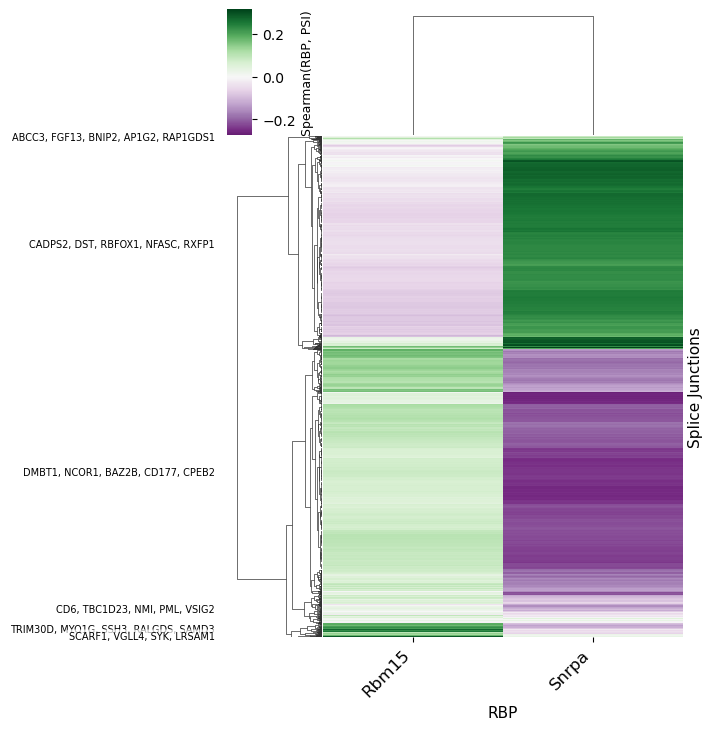

In [64]:
from scipy.cluster.hierarchy import fcluster
import os
import pandas as pd
import seaborn as sns

# 1) Build matrix and draw clustermap
corr_matrix = corr_df.pivot_table(index="junction_id", columns="RBP", values="rho")
g = sns.clustermap(
    corr_matrix, cmap="PRGn", center=0, figsize=(5,7),
    xticklabels=True, yticklabels=False
)

# X-axis ticks formatting
for lbl in g.ax_heatmap.get_xticklabels():
    lbl.set_rotation(45)
    lbl.set_horizontalalignment("right")
    lbl.set_fontsize(12)  # increased font size

# Axis labels
g.ax_cbar.set_ylabel("Spearman(RBP, PSI)", fontsize=9)
g.ax_heatmap.set_xlabel("RBP", fontsize=11)
g.ax_heatmap.set_ylabel("Splice Junctions", fontsize=11)

# 2) Map junction_id -> gene_name
var_idx = splicing_aging.var.set_index("junction_id")
gene_col = "gene_name" if "gene_name" in var_idx.columns else "gene"
jid2gene = var_idx[gene_col].to_dict()

# 3) Cut dendrogram into K modules
Z = g.dendrogram_row.linkage
K = 6
cluster_labels = fcluster(Z, K, criterion="maxclust")

# 3.1) Module map (junction_id -> module), ordered top→bottom in the plot
row_order = [corr_matrix.index[i] for i in g.dendrogram_row.reordered_ind]
labels_series = pd.Series(cluster_labels, index=corr_matrix.index)
ordered_labels = labels_series.loc[row_order]
label_order_map = {old: new for new, old in enumerate(pd.unique(ordered_labels), start=1)}
module_map = {jid: label_order_map[lab] for jid, lab in labels_series.items()}

# 4) Row order & contiguous blocks
clust_by_row = pd.Series(cluster_labels, index=corr_matrix.index).loc[row_order].values

blocks, start = [], 0
for i in range(1, len(row_order)+1):
    if i == len(row_order) or clust_by_row[i] != clust_by_row[i-1]:
        blocks.append((clust_by_row[i-1], start, i-1))
        start = i

# 5) Annotate each block with top gene names ONLY
for cid, i0, i1 in blocks:
    rows = row_order[i0:i1+1]
    genes = [jid2gene.get(j, j) for j in rows]
    top = (pd.Series(genes).value_counts().head(5).index.tolist())
    label = ", ".join(top)
    
    y_mid = (i0 + i1) / 2.0
    g.ax_heatmap.text(
        -0.6, y_mid, label,
        ha="right", va="center", fontsize=7,
        transform=g.ax_heatmap.transData, clip_on=False,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

# --- Save ---
os.makedirs(paths["output_dir"], exist_ok=True)
out_path = os.path.join(paths["output_dir"], "RBP_vs_splice_junctions.pdf")
g.fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")

# Tag correlations with module id
corr_df["Module"] = corr_df["junction_id"].map(module_map)

# All junctions per module sorted by |rho|
top_per_module = (
    corr_df
    .assign(abs_rho=lambda d: d["rho"].abs())
    .sort_values("abs_rho", ascending=False)
    .groupby("Module", group_keys=False)
    .apply(lambda x: x.sort_values("abs_rho", ascending=False))
    .reset_index(drop=True)
)

# Add gene names
corr_df_genes = splicing_aging.var.set_index("junction_id")[[gene_col]]
top_per_module = top_per_module.merge(
    corr_df_genes, 
    left_on="junction_id", 
    right_index=True, 
    how="left"
)

# Save a table for Panel B
output_file = os.path.join(paths["output_dir"], "top_junctions_per_module.csv")
top_per_module.to_csv(output_file, index=False)
print("Saved:", output_file)

# Show all genes in top_per_module
print("\nAll genes in top_per_module:")
print(top_per_module[gene_col].value_counts())

In [65]:
top_per_module[top_per_module["gene_name"] == "RBFOX1"]

,CellType,RBP,junction_id,Program,rho,pval,Module,abs_rho,gene_name
152,Microglia,Snrpa,chr16_7070085_7224310_+,SP1,0.273205,2.037497e-205,2,0.273205,RBFOX1
1187,Microglia,Snrpa,chr16_7040025_7224310_+,SP2,-0.234213,5.879960e-150,3,0.234213,RBFOX1
1264,Microglia,Snrpa,chr16_7375969_7407963_+,SP1,0.232386,1.356756e-147,2,0.232386,RBFOX1
1326,Microglia,Snrpa,chr16_6349231_6487818_+,SP1,0.230647,2.314117e-145,2,0.230647,RBFOX1
2118,Microglia,Snrpa,chr16_7353064_7375904_+,SP2,-0.203416,8.009322e-113,3,0.203416,RBFOX1
2557,Microglia,Snrpa,chr16_6173667_6487818_+,SP1,0.166570,9.194251e-76,2,0.166570,RBFOX1
2631,Microglia,Snrpa,chr16_7294130_7306407_+,SP2,-0.160391,2.598828e-70,3,0.160391,RBFOX1
3313,Microglia,Rbm15,chr16_7353064_7375904_+,SP2,0.095810,5.364364e-26,3,0.095810,RBFOX1
3807,Microglia,Rbm15,chr16_7040025_7224310_+,SP2,0.078124,8.568973e-18,3,0.078124,RBFOX1
4313,Microglia,Rbm15,chr16_7294130_7306407_+,SP2,0.067150,1.560756e-13,3,0.067150,RBFOX1


In [66]:
top_per_module[top_per_module["gene_name"] == "RBFOX3"]

,CellType,RBP,junction_id,Program,rho,pval,Module,abs_rho,gene_name
491,Microglia,Snrpa,chr11_118513404_118610158_-,SP1,0.252427,1.164369e-174,2,0.252427,RBFOX3
1099,Microglia,Snrpa,chr11_118503773_118503929_-,SP1,0.236085,2.119276e-152,2,0.236085,RBFOX3
1105,Microglia,Snrpa,chr11_118501629_118503719_-,SP1,0.236002,2.716036e-152,2,0.236002,RBFOX3
4368,Microglia,Rbm15,chr11_118513404_118610158_-,SP1,-0.065827,4.618247e-13,2,0.065827,RBFOX3
5163,Microglia,Rbm15,chr11_118503773_118503929_-,SP1,-0.045071,7.362087e-07,2,0.045071,RBFOX3
5168,Microglia,Rbm15,chr11_118501629_118503719_-,SP1,-0.044820,8.480893e-07,2,0.044820,RBFOX3


In [67]:
# Filter to just the RBPs of interest
df_sub = corr_df[corr_df['RBP'].isin(['Snrpa', 'Rbm15'])].copy()

# Pivot to have Snrpa and Rbm15 rhos side by side for each junction
pivoted = df_sub.pivot_table(
    index=['CellType', 'junction_id', 'Module', 'Program'], 
    columns='RBP',
    values='rho'
).reset_index()

# Keep only rows where both RBPs are present
pivoted = pivoted.dropna(subset=['Snrpa', 'Rbm15'])

# Filter for opposite signs
opposite_corr = pivoted[
    (pivoted['Snrpa'] > 0) & (pivoted['Rbm15'] < 0) |
    (pivoted['Snrpa'] < 0) & (pivoted['Rbm15'] > 0)
].copy()

# Optionally, sort by magnitude of difference
opposite_corr['abs_diff'] = (pivoted['Snrpa'] - pivoted['Rbm15']).abs()
opposite_corr = opposite_corr.sort_values('abs_diff', ascending=False)

print(opposite_corr.head(20))


RBP    CellType                 junction_id  Module Program     Rbm15  \
1925  Microglia    chr4_43643174_43643334_+       5     SP2  0.197233   
1465  Microglia  chr2_125114050_125115437_-       5     SP2  0.225468   
78    Microglia   chr10_61475889_61482335_+       3     SP2  0.168904   
1495  Microglia  chr2_154592363_154596201_-       3     SP2  0.156417   
651   Microglia   chr14_57602666_57603585_-       3     SP2  0.157754   
2819  Microglia    chr9_96003942_96005996_+       3     SP2  0.152615   
2593  Microglia    chr8_47712294_47712887_-       3     SP2  0.162265   
1033  Microglia   chr17_55952928_55953888_+       3     SP2  0.177361   
331   Microglia   chr11_78032703_78034012_+       3     SP2  0.184737   
962   Microglia   chr17_29361157_29363710_+       3     SP2  0.169270   
2388  Microglia    chr7_19697614_19698187_-       3     SP2  0.159713   
2163  Microglia  chr6_123139408_123140655_+       3     SP2  0.163434   
278   Microglia   chr11_61142529_61146840_+       5

In [68]:
corr_df[corr_df["Module"] == 1]

,CellType,RBP,junction_id,Program,rho,pval,Module
248,Microglia,Rbm15,chr11_46342480_46347870_-,SP2,0.058956,9.205726e-11,1
346,Microglia,Rbm15,chr11_94359940_94361171_-,SP1,0.070830,6.841925e-15,1
347,Microglia,Rbm15,chr11_94359943_94361171_-,SP2,0.019771,2.991720e-02,1
642,Microglia,Rbm15,chr14_55104658_55104830_-,SP2,0.086922,1.147388e-21,1
758,Microglia,Rbm15,chr15_82403338_82403718_-,SP2,0.043164,2.117651e-06,1
1026,Microglia,Rbm15,chr17_49452842_49454029_+,SP2,0.013572,1.361254e-01,1
1132,Microglia,Rbm15,chr18_67133970_67134212_+,SP2,-0.004803,5.979061e-01,1
1257,Microglia,Rbm15,chr1_135849460_135850378_+,SP1,0.071228,4.829829e-15,1
1538,Microglia,Rbm15,chr2_181502053_181502875_+,SP2,0.030864,6.991587e-04,1
1696,Microglia,Rbm15,chr3_138965996_138983721_-,SP2,0.066995,1.773959e-13,1


Event: ENSMUSG00000028469.15_atse_2  Gene: NPR2  (n junctions: 3)

- junction_id: chr4_43643174_43643334_+
  junction_id_index: 23163
  annotation_status: both


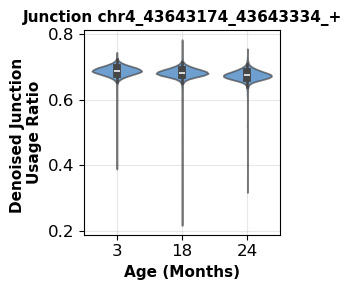

- junction_id: chr4_43643174_43643605_+
  junction_id_index: 23164
  annotation_status: both


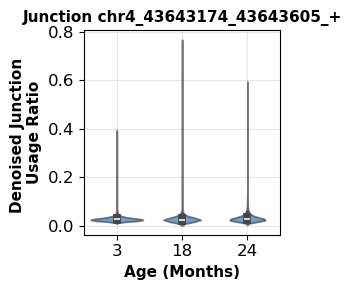

- junction_id: chr4_43643409_43643605_+
  junction_id_index: 23165
  annotation_status: both


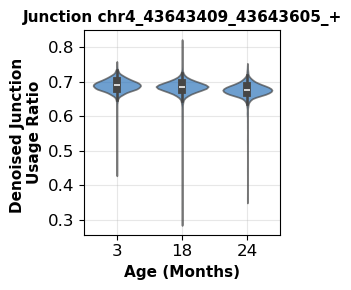

In [69]:
# choose one object name; I'll use splicing_aging everywhere
junc = "chr4_43643174_43643334_+"

# 1) pull the event and all junctions in that event
row = splicing_aging.var.loc[splicing_aging.var["junction_id"] == junc]
assert len(row) == 1, f"junction_id not unique/found: {junc}"
event_id = row["event_id"].iloc[0]
gene_name = row["gene_name"].iloc[0]

subset = splicing_aging.var.loc[splicing_aging.var["event_id"] == event_id]

# aligned arrays
all_idx = subset["junction_id_index"].to_numpy()   # integer indices into .var (your plot fn expects this)
all_ids = subset["junction_id"].to_numpy()
annots  = subset["annotation_status"].to_numpy()

print(f"Event: {event_id}  Gene: {gene_name}  (n junctions: {len(all_ids)})\n")

# 2) subset the AnnData once to Microglia
micro = splicing_aging[splicing_aging.obs["medium_cell_type"] == "Microglia"].copy()

# 3) loop and print + plot
for jid, jidx, ann in zip(all_ids, all_idx, annots):
    print(f"- junction_id: {jid}")
    print(f"  junction_id_index: {jidx}")
    print(f"  annotation_status: {ann}")
    # plot; your function takes a var index (junction_idx)
    plot_psi_by_age_violin(
        micro,
        junction_idx=jidx,
        OUTPUT_DIR=None,
        figsize=(3, 3)
    )


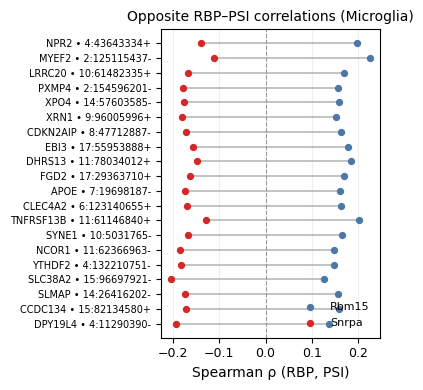

In [70]:
# --- build top opposite-correlation junctions (Microglia only) ---
rbps = ["Rbm15", "Snrpa"]
df_sub = (corr_df
          .query("CellType == 'Microglia' and RBP in @rbps")
          .copy())

# pick ONE row per (junction,RBP): the strongest association across SP1/SP2
rep = (df_sub
       .sort_values("rho", key=lambda s: s.abs(), ascending=False)
       .drop_duplicates(["junction_id", "RBP"]))

# wide table: junction x RBP with rho
wide = (rep.pivot(index="junction_id", columns="RBP", values="rho")
            .dropna(subset=rbps))

# keep opposite-sign pairs
opp = wide[(wide["Rbm15"] * wide["Snrpa"]) < 0].copy()
opp["rho_diff"] = (opp["Snrpa"] - opp["Rbm15"]).abs()

# add gene names (optional)
var_idx = splicing_aging.var.set_index("junction_id")
gene_col = "gene_name" if "gene_name" in var_idx.columns else "gene"
opp["gene"] = opp.index.map(lambda j: var_idx.at[j, gene_col] if j in var_idx.index else j)

# pick top N
N = 20
top_opp = opp.sort_values("rho_diff", ascending=False).head(N).copy()

# build a tidy frame for plotting
plot_df = (top_opp
           .assign(label=lambda d: d["gene"] + " • " + d.index.str.replace(r"chr(\w+)_.*?_(\d+)_([+-])", r"\1:\2\3", regex=True))
           .reset_index(drop=False))


fig, ax = plt.subplots(figsize=(4.0, 4.0))
y = np.arange(len(plot_df))[::-1]  # top to bottom

# lines connecting the two RBPs
for i, row in plot_df.iterrows():
    ax.plot([row["Rbm15"], row["Snrpa"]], [y[i], y[i]],
            lw=1.1, color="0.7", zorder=1)

# points for each RBP
ax.scatter(plot_df["Rbm15"], y, label="Rbm15", s=18, color="#4c78a8", zorder=2, rasterized=True)
ax.scatter(plot_df["Snrpa"], y, label="Snrpa", s=18, color="#d62728", zorder=3, rasterized=True)

# cosmetics
ax.axvline(0, ls="--", lw=0.8, color="0.6")
ax.set_yticks(y)
ax.set_yticklabels(plot_df["label"], fontsize=7)
ax.set_xlabel("Spearman ρ (RBP, PSI)", fontsize=10)
ax.set_title("Opposite RBP–PSI correlations (Microglia)", fontsize=10, pad=6)
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.grid(True, axis="x", alpha=0.2)
ax.tick_params(axis="x", labelsize=9)

plt.tight_layout()
# save next to your figure set if you want:
# fig.savefig(os.path.join(paths["output_dir"], "panel_opposite_RBM15_SNRPA.pdf"), bbox_inches="tight")
plt.show()

In [71]:
plot_df

RBP,junction_id,Rbm15,Snrpa,rho_diff,gene,label
0,chr4_43643174_43643334_+,0.197233,-0.139358,0.336591,NPR2,NPR2 • 4:43643334+
1,chr2_125114050_125115437_-,0.225468,-0.110343,0.335811,MYEF2,MYEF2 • 2:125115437-
2,chr10_61475889_61482335_+,0.168904,-0.166702,0.335607,LRRC20,LRRC20 • 10:61482335+
3,chr2_154592363_154596201_-,0.156417,-0.177497,0.333914,PXMP4,PXMP4 • 2:154596201-
4,chr14_57602666_57603585_-,0.157754,-0.176048,0.333802,XPO4,XPO4 • 14:57603585-
5,chr9_96003942_96005996_+,0.152615,-0.181090,0.333705,XRN1,XRN1 • 9:96005996+
6,chr8_47712294_47712887_-,0.162265,-0.170840,0.333105,CDKN2AIP,CDKN2AIP • 8:47712887-
7,chr17_55952928_55953888_+,0.177361,-0.155567,0.332927,EBI3,EBI3 • 17:55953888+
8,chr11_78032703_78034012_+,0.184737,-0.148104,0.332840,DHRS13,DHRS13 • 11:78034012+
9,chr17_29361157_29363710_+,0.169270,-0.163152,0.332422,FGD2,FGD2 • 17:29363710+


## Downstream plotting

In [72]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import spearmanr

# ----------------- small helpers -----------------
def _cells(splicing_aging, cell_type=None):
    if cell_type is None:
        return splicing_aging.obs_names
    return splicing_aging.obs_names[splicing_aging.obs["medium_cell_type"] == cell_type]

def _psi_for_junction(splicing_aging, junction_id, cells):
    # map junction_id -> var position
    try:
        pos = splicing_aging.var.index.get_loc(junction_id)
    except KeyError:
        # if var index is numeric, match by column
        pos = np.where(splicing_aging.var["junction_id"].values == junction_id)[0]
        if len(pos) == 0:
            raise KeyError(f"junction_id not found: {junction_id}")
        pos = pos[0]
    X = splicing_aging.layers["denoised_PSI"][splicing_aging.obs_names.isin(cells), :][:, pos]
    return np.asarray(X).ravel()

def _rbp_expr(ge_adata_aging, rbp, cells):
    return np.asarray(ge_adata_aging[cells, rbp].layers["scVI_linear"]).ravel()

def _sp_val(splicing_aging, program, cells):
    return splicing_aging.obs.loc[cells, program].to_numpy()

def _annotate_spearman(ax, x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() >= 10:
        r, p = spearmanr(x[m], y[m])
        ax.text(0.02, 0.98, f"ρ={r:.3f}\np={p:.1e}", ha="left", va="top",
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))

# ----------------- 1) RBP vs junction PSI -----------------
def plot_rbp_vs_junction(splicing_aging, ge_adata_aging, rbp, junction_id,
                         cell_type=None, use_hex=False, figsize=(4,4), title=None, levels=6):
    cells = _cells(splicing_aging, cell_type)
    x = _rbp_expr(ge_adata_aging, rbp, cells)
    y = _psi_for_junction(splicing_aging, junction_id, cells)

    fig, ax = plt.subplots(figsize=figsize)
    _scatter_or_kde(ax, x, y, use_hex=use_hex, levels=levels)
    _annotate_spearman(ax, x, y)
    ax.set_xlabel(f"{rbp} (scVI linear)")
    ax.set_ylabel(f"PSI: {junction_id}")
    ttl = title or (f"{rbp} vs PSI\n" + (cell_type if cell_type else "All cells"))
    ax.set_title(ttl)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    return fig, ax

# ----------------- 2) SP1 vs SP2 density/contour -----------------
def _scatter_or_kde(
    ax, x, y, use_hex=False, levels=6,
    cmap="Blues", fill_alpha=0.35,
    line_color="black", line_width=0.9,
    bw_adjust=1.0, dot_color="#1f77b4"
):
    if use_hex:
        ax.hexbin(x, y, gridsize=60, linewidths=0, mincnt=1, rasterized=True)
    else:
        sns.kdeplot(
            x=x, y=y, fill=True, cmap=cmap, levels=levels,
            bw_adjust=bw_adjust, thresh=0.02, alpha=fill_alpha, ax=ax
        )
        sns.kdeplot(
            x=x, y=y, fill=False, color=line_color, levels=levels,
            bw_adjust=bw_adjust, thresh=0.02, linewidths=line_width, ax=ax
        )
        ax.scatter(
            x, y, s=5, alpha=0.25, color=dot_color,
            rasterized=True  # ⬅ key change
        )

def plot_sp1_vs_sp2(
    splicing_aging, cell_type=None, use_hex=False, figsize=(4,4),
    title=None, levels=6, output_dir=None
):
    cells = _cells(splicing_aging, cell_type)
    x = _sp_val(splicing_aging, "SP_1", cells)
    y = _sp_val(splicing_aging, "SP_2", cells)

    fig, ax = plt.subplots(figsize=figsize)
    _scatter_or_kde(ax, x, y, use_hex=use_hex, levels=levels, dot_color="#1f77b4")
    _annotate_spearman(ax, x, y)
    ax.axhline(0, ls="--", lw=0.6, color="gray", alpha=0.6)
    ax.axvline(0, ls="--", lw=0.6, color="gray", alpha=0.6)
    ax.set_xlabel("SP1 activity")
    ax.set_ylabel("SP2 activity")
    ttl = title or (f"SP1 vs SP2\n" + (cell_type if cell_type else "All cells"))
    ax.set_title(ttl)
    ax.grid(True, alpha=0.2)

    # increase tick font size
    ax.tick_params(axis="both", labelsize=12)

    plt.tight_layout()

    # Save if requested
    if output_dir is not None:
        import os
        fname = f"sp1_vs_sp2_{cell_type if cell_type else 'all'}.pdf"
        path = os.path.join(output_dir, fname)
        fig.savefig(path, format="pdf", bbox_inches="tight")
        print(f"Saved SP1 vs SP2 plot to: {path}")

    return fig, ax

# ----------------- 3) SP(1/2) vs RBP density/contour -----------------
def plot_sp_vs_rbp(splicing_aging, ge_adata_aging, rbp, program="SP_1",
                   cell_type=None, use_hex=False, figsize=(4,4), title=None, levels=6):
    cells = _cells(splicing_aging, cell_type)
    x = _sp_val(splicing_aging, program, cells)         # x-axis = SP activity
    y = _rbp_expr(ge_adata_aging, rbp, cells)           # y-axis = RBP expression

    fig, ax = plt.subplots(figsize=figsize)
    _scatter_or_kde(ax, x, y, use_hex=use_hex, levels=levels)
    _annotate_spearman(ax, x, y)
    ax.set_xlabel(f"{program} activity")
    ax.set_ylabel(f"{rbp} (scVI linear)")
    ttl = title or (f"{program} vs {rbp}\n" + (cell_type if cell_type else "All cells"))
    ax.set_title(ttl)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    return fig, ax

In [73]:
def plot_gene_expression_vs_agegroup(adata, gene_name, cell_type, ax=None):
    """
    Gene expression vs age (violin + box), ordered from smallest to largest age.
    Uses values from adata.layers["scVI_linear"].
    """
    # Locate gene index
    if gene_name in adata.var_names:
        gene_idx = adata.var_names.get_loc(gene_name)
    elif "gene_name" in adata.var.columns:
        matches = np.where(adata.var["gene_name"].values == gene_name)[0]
        if len(matches) == 0:
            raise ValueError(f"Gene {gene_name} not found.")
        gene_idx = matches[0]
    else:
        raise ValueError(f"Gene {gene_name} not found in var_names or var['gene_name'].")

    # Filter cells of given type
    mask = adata.obs["medium_cell_type"] == cell_type

    # Extract expression from scVI_linear layer
    expr = np.asarray(adata.layers["scVI_linear"][mask, gene_idx]).ravel()

    # Numeric age
    age = adata.obs.loc[mask, "age_numeric"].astype(float).values

    df = pd.DataFrame({"Expression": expr, "age_numeric": age})

    # Order by smallest → largest age
    age_order = np.sort(df["age_numeric"].unique())
    df["age_numeric"] = pd.Categorical(df["age_numeric"], categories=age_order, ordered=True)

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.6, 2.8))

    sns.violinplot(
        data=df, x="age_numeric", y="Expression",
        order=age_order, inner="box", cut=0, scale="width",
        linewidth=0.8, ax=ax
    )

    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Expression")
    ax.set_title(f"{gene_name}: Expression vs age — {cell_type}")
    ax.grid(True, axis="y", alpha=0.2)
    ax.set_xticklabels(
        [str(int(a)) if float(a).is_integer() else f"{a:.1f}" for a in age_order],
        rotation=30, ha="right"
    )

    return ax

In [74]:
ge_adata_aging

AnnData object with n_obs × n_vars = 84047 × 2482
    obs: 'cell_id', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'tissue', 'dataset', 'batch', 'subtissue_clean', 'broad_cell_type', 'cell_id_index', 'specific_cell_type', 'medium_cell_type', 'cell_name', 'library_size', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_is_rRNA', 'log1p_total_counts_is_rRNA', 'pct_counts_is_rRNA', 'nuclear_score_log_norm', 'nuclear_ratio_log_norm', 'nuclear_rrna_log_norm', 'nuclear_class_log_norm', 'nuclear_score_predicted_log_norm_tms', 'nuclear_ratio_predicted_log_norm_tms', 'nuclear_rrna_predicted_log_norm_tms', 'nuclear_class_predicted_log_norm_tms', 'AgingScore_pos', 'AgingScore_neg', 'AgingScore_unweighted', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'age_numeric', 'SP_1', 'SP_2'
    var: 'index', 'gene_name', 'gene_id', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'transcript_biotypes', 'is_rRNA', 'n_cells_by_counts', 

In [76]:
# plot_gene_expression_vs_agegroup(ge_adata_aging, "Cpeb3", "Microglia")

<Axes: title={'center': 'Junction 10607: PSI vs age — Microglia'}, xlabel='Age (years)', ylabel='PSI'>

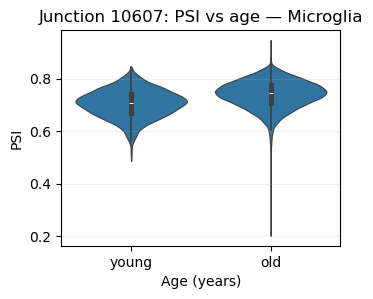

In [77]:
def plot_psi_vs_agegroup(splicing_aging, junction_id_index, cell_type, ax=None):
    """
    PSI vs age (violin + box), ordered from smallest to largest age.
    junction_id_index is the column index in splicing_aging (0..n_vars-1).
    """
    # Cells of interest (keep original order)
    mask = splicing_aging.obs["medium_cell_type"] == cell_type

    # PSI for the junction
    y = np.asarray(splicing_aging.layers["denoised_PSI"][mask, junction_id_index]).ravel()

    # Numeric age
    age = splicing_aging.obs.loc[mask, "age_group"]

    df = pd.DataFrame({"PSI": y, "age_group": age})

    # Order ages smallest → largest
    age_order = ["young", "old"]
    df["age_group"] = pd.Categorical(df["age_group"], categories=age_order, ordered=True)

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.6, 2.8))

    # Violin (distribution shape)
    sns.violinplot(
        data=df, x="age_group", y="PSI",
        order=age_order, inner="box", cut=0, scale="width",
        linewidth=0.8, ax=ax
    )

    ax.set_xlabel("Age (years)")
    ax.set_ylabel("PSI")
    ax.set_title(f"Junction {junction_id_index}: PSI vs age — {cell_type}")
    ax.grid(True, axis="y", alpha=0.2)

    return ax

plot_psi_vs_agegroup(splicing_aging, 10607, "Microglia")

Saved SP1 vs SP2 plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/sp1_vs_sp2_all.pdf


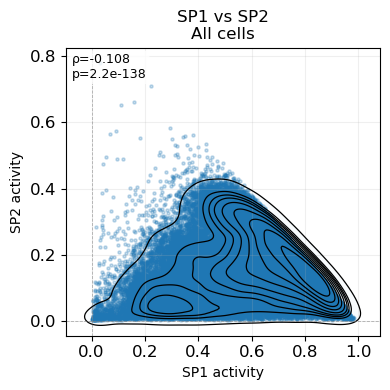

In [78]:
# 2) SP1 vs SP2 (all cells)
fig, ax = plot_sp1_vs_sp2(splicing_aging[splicing_aging.obs["medium_cell_type"].isin(overlapping_cell_types)], cell_type=None, levels=10, output_dir=paths["output_dir"])

## Visualize relevant ATSEs

In [79]:
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
)

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

In [80]:
junc_idx=13111
splice_adata.var[splice_adata.var["junction_id_index"] == junc_idx]

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,...,mean_counts_per_cell,junction_variability,annotation_status_score,expression_breadth_score,read_count_score,variability_score,conservation_score,junction_id_index,RBP_gene,Aging_gene
13111,chr18_43531964_43540585_-,ENSMUSG00000024502.9_atse_3,GT-AG,both,JAKMIP2,ENSMUSG00000024502,3,1.0,0.0,3979,...,14.421769,0.500891,0.8,0.0,7.659643,1.0,2.0,13111,False,False


Unique transcripts: ['ENSMUST00000082254.6']
Unique transcripts to remove: []
Plot saved to mouse_ENSMUSG00000024502.9_atse_3.pdf!


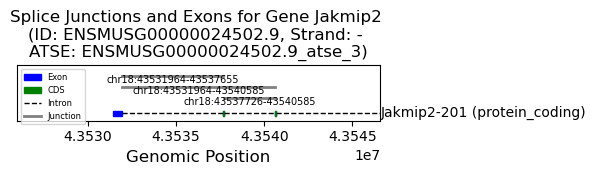

ATSE visualization saved: mouse_ENSMUSG00000024502.9_atse_3.pdf


{'junctions':                           event_id               gene_id gene_name  \
 20732  ENSMUSG00000024502.9_atse_3  ENSMUSG00000024502.9   Jakmip2   
 20733  ENSMUSG00000024502.9_atse_3  ENSMUSG00000024502.9   Jakmip2   
 20734  ENSMUSG00000024502.9_atse_3  ENSMUSG00000024502.9   Jakmip2   
 
            gene_types  num_junctions event_type chromosome strand  atse_start  \
 20732  protein_coding              3    complex      chr18      -    43531964   
 20733  protein_coding              3    complex      chr18      -    43531964   
 20734  protein_coding              3    complex      chr18      -    43531964   
 
        atse_end  ...  donor_total_reads  acceptor_total_reads  splice_motif  \
 20732  43540585  ...             131410                127431         GT-AG   
 20733  43540585  ...             143304                131410         GT-AG   
 20734  43540585  ...             140077                143304         GT-AG   
 
        donor_seq  acceptor_seq  position_off_5_p

In [81]:
junction_id="chr18_43531964_43540585_-"
event= splice_adata.var[splice_adata.var["junction_id"] == junction_id]["event_id"].values[0]
visualize_atse_event(event, atse_df, db_mouse,
                     base_width=6,
                 species="mouse", show_usage=False, 
                 trans_height=0.7,
                  show_junc_lines=False)